# Análisis Exploratorio para Modelado  
## Proyecto Final: Smart Supply Chain

Este notebook tiene como objetivo realizar una revisión exploratoria inicial de las tablas analíticas `tad_pedidos` y `tad_ventas`, las cuales fueron construidas durante el proceso ETL y cargadas a BigQuery para alimentar el dashboard en Looker Studio.

Antes de construir modelos de minería de datos, es necesario revisar la estructura de las tablas, su granularidad, tipos de datos, llaves, valores nulos, variables disponibles y posibles problemas de calidad.  

Esta revisión permite justificar la selección posterior de variables para el modelo supervisado y para el clustering de sellers.

## 1. Carga de librerías

Se cargan las librerías necesarias para el análisis exploratorio.  
Principalmente se utiliza `pandas` para manipulación de datos, `numpy` para operaciones numéricas y librerías de visualización para análisis posteriores.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_DIR = os.environ.get('CSV_DIR', '../CSV')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Helpers de visualizacion: encapsulan el patron plt.figure -> plt.bar/barh -> plt.show.
def plot_bar(labels, values, title, ylabel='', xlabel='', figsize=(7, 4), rotation=0):
    plt.figure(figsize=figsize)
    plt.bar([str(l) for l in labels], values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if rotation:
        plt.xticks(rotation=rotation, ha='right')
    plt.show()

def plot_barh_top(df, col_label, col_value, top_n, title, xlabel='', ylabel='', figsize=(8, 5)):
    top = df.head(top_n)
    plt.figure(figsize=figsize)
    plt.barh(top[col_label], top[col_value])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


## 2. Carga de datos

Se cargan las dos tablas analíticas finales generadas durante el ETL:

- `tad_pedidos`: tabla con granularidad de una fila por pedido.
- `tad_ventas`: tabla con granularidad de una fila por producto vendido dentro de una orden.

Estas tablas son las mismas que fueron utilizadas para alimentar el dashboard en Looker Studio.

In [2]:
import os

CSV_DIR = os.environ.get('CSV_DIR', '../CSV')

tad_pedidos = pd.read_csv(os.path.join(CSV_DIR, '02_tad_pedidos.csv'))
tad_ventas  = pd.read_csv(os.path.join(CSV_DIR, '02_tad_ventas.csv'))

print('Carga completada.')
print('Dimensiones de tad_pedidos:', tad_pedidos.shape)
print('Dimensiones de tad_ventas :', tad_ventas.shape)


Carga completada.
Dimensiones de tad_pedidos: (99441, 42)
Dimensiones de tad_ventas : (112650, 55)


## 3. Revisión inicial de las tablas

En esta sección se revisan las dimensiones generales de las tablas, sus primeras observaciones y la estructura de columnas disponibles.

Esta revisión permite confirmar que cada tabla mantiene la unidad de análisis esperada:

- `tad_pedidos`: una fila por pedido.
- `tad_ventas`: una fila por combinación de pedido e ítem vendido.

In [3]:
print("Primeras filas de tad_pedidos")
display(tad_pedidos.head())

print("Primeras filas de tad_ventas")
display(tad_ventas.head())

Primeras filas de tad_pedidos


,order_id,customer_id,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,geo_lat,geo_lng,geo_city,geo_state,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,fecha,fecha_key,anio,mes,dia,trimestre,dia_semana_num,dia_semana_nombre,es_fin_semana,num_items,tiene_items,payment_type,payment_installments,payment_value,review_score,flag_short_message,flag_answer_before_creation,flag_review_id_duplicated,flag_review_id_multi_order,delivery_days_real,delivery_days_estimated,delivery_delay_days,is_late_delivery,is_delivered,is_bad_review,is_good_review
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,3149,-23.58,-46.59,sao paulo,SP,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,20171002,2017,10,2,4,0,Monday,0,1,1,voucher,1.00,38.71,4.00,False,False,False,False,8.00,15,-8.00,0,1,0,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,47813,-12.19,-44.54,barreiras,BA,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-24,20180724,2018,7,24,3,1,Tuesday,0,1,1,boleto,1.00,141.46,4.00,False,False,False,False,13.00,19,-6.00,0,1,0,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,75265,-16.75,-48.51,vianopolis,GO,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,20180808,2018,8,8,3,2,Wednesday,0,1,1,credit_card,3.00,179.12,5.00,False,False,False,False,9.00,26,-18.00,0,1,0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,59296,-5.77,-35.27,sao goncalo do amarante,RN,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-18,20171118,2017,11,18,4,5,Saturday,1,1,1,credit_card,1.00,72.20,5.00,False,False,False,False,13.00,26,-13.00,0,1,0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,9195,-23.68,-46.51,santo andre,SP,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-13,20180213,2018,2,13,1,1,Tuesday,0,1,1,credit_card,1.00,28.62,5.00,False,False,False,False,2.00,12,-10.00,0,1,0,1


Primeras filas de tad_ventas


,order_id,order_item_id,customer_id,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,geo_lat,geo_lng,geo_city,geo_state,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,seller_id,seller_city,seller_state,seller_zip_code_prefix,seller_geo_lat,seller_geo_lng,payment_type,payment_installments,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,anio,mes,dia,trimestre,dia_semana_num,dia_semana_nombre,es_fin_semana,price,freight_value,total_item_value,payment_value_item,review_score,delivery_days_real,delivery_days_estimated,delivery_delay_days,is_late_delivery,is_delivered,is_bad_review,is_good_review
0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,28013,-21.76,-41.31,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,Cool Stuff,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,"3,528.00",48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,-22.50,-44.13,credit_card,2.00,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,2017,9,13,3,2,Wednesday,0,58.90,13.29,72.19,72.19,5.00,7.00,15,-9.00,0,1,0,1
1,00018f77f2f0320c557190d7a144bdd3,1,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,15775,-20.22,-50.90,santa fe do sul,SP,e5f2d52b802189ee658865ca93d83a8f,Pet Shop,pet_shop,56.00,239.00,2.00,"30,000.00",50.00,30.00,40.00,"60,000.00",dd7ddc04e1b6c2c614352b383efe2d36,sao paulo,SP,3471,-23.57,-46.52,credit_card,3.00,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,2017,4,26,2,2,Wednesday,0,239.90,19.93,259.83,259.83,4.00,16.00,18,-3.00,0,1,0,1
2,000229ec398224ef6ca0657da4fc703e,1,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,35661,-19.87,-44.59,para de minas,MG,c777355d18b72b67abbeef9df44fd0fd,Moveis Decoracao,furniture_decor,59.00,695.00,2.00,"3,050.00",33.00,13.00,33.00,"14,157.00",5b51032eddd242adc84c38acab88f23d,borda da mata,MG,37564,-22.26,-46.17,credit_card,5.00,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,2018,1,14,1,6,Sunday,1,199.00,17.87,216.87,216.87,5.00,7.00,21,-14.00,0,1,0,1
3,00024acbcdf0a6daa1e931b038114c75,1,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,12952,-23.11,-46.59,atibaia,SP,7634da152a4610f1595efa32f14722fc,Perfumaria,perfumery,42.00,480.00,1.00,200.00,16.00,10.00,15.00,"2,400.00",9d7a1d34a5052409006425275ba1c2b4,franca,SP,14403,-20.55,-47.39,credit_card,2.00,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,2018,8,8,3,2,Wednesday,0,12.99,12.79,25.78,25.78,4.00,6.00,11,-6.00,0,1,0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,13226,-23.24,-46.83,varzea paulista,SP,ac6c3623068f30de03045865e4e10089,Ferramentas Jardim,garden_tools,59.00,409.00,1.00,"3,750.00",35.00,40.00,30.00,"42,000.00",df560393f3a51e74553ab94004ba5c87,loanda,PR,87900,-22.93,-53.14,credit_card,3.00,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,2017,2,4,1,5,Saturday,1,199.90,18.14,218.04,218.04,5.00,25.00,40,-16.00,0,1,0,1


In [4]:
resumen_tablas = pd.DataFrame({
    "tabla": ["tad_pedidos", "tad_ventas"],
    "filas": [tad_pedidos.shape[0], tad_ventas.shape[0]],
    "columnas": [tad_pedidos.shape[1], tad_ventas.shape[1]],
    "unidad_analisis": [
        "Una fila por pedido",
        "Una fila por producto vendido dentro de una orden"
    ],
    "llave_logica": [
        "order_id",
        "order_id + order_item_id"
    ]
})

display(resumen_tablas)

,tabla,filas,columnas,unidad_analisis,llave_logica
0,tad_pedidos,99441,42,Una fila por pedido,order_id
1,tad_ventas,112650,55,Una fila por producto vendido dentro de una orden,order_id + order_item_id


### Interpretación

La tabla `tad_pedidos` se utiliza para análisis logístico, experiencia del cliente y métricas generales de pedidos, ya que conserva una fila por cada `order_id`.

La tabla `tad_ventas` se utiliza para análisis comercial, productos, categorías y sellers, ya que conserva el detalle de cada producto vendido dentro de una orden.

Esta separación evita duplicar métricas de pedidos cuando una orden contiene más de un producto.

## 4. Revisión de estructura de datos

La revisión de estructura permite conocer el tipo de dato de cada variable, identificar columnas numéricas, categóricas, temporales y binarias, además de validar si las llaves principales mantienen la granularidad esperada.

Este paso es importante porque antes de aplicar modelos de minería de datos se debe verificar que las variables estén correctamente interpretadas y que no existan problemas evidentes de duplicidad en la unidad de análisis.

In [5]:
def resumen_estructura(df, nombre_tabla):
    return pd.DataFrame({
        'tabla': nombre_tabla,
        'columna': df.columns,
        'tipo_dato': df.dtypes.astype(str).values,
        'valores_no_nulos': df.notnull().sum().values,
        'valores_nulos': df.isnull().sum().values,
        'porcentaje_nulos': (df.isnull().mean() * 100).round(2).values,
        'valores_unicos': df.nunique(dropna=True).values,
    })

tablas = {'tad_pedidos': tad_pedidos, 'tad_ventas': tad_ventas}
estructuras = {nombre: resumen_estructura(df, nombre) for nombre, df in tablas.items()}

# Se conservan referencias por nombre para celdas posteriores.
estructura_pedidos = estructuras['tad_pedidos']
estructura_ventas  = estructuras['tad_ventas']

for nombre, df_resumen in estructuras.items():
    print(f'Estructura · {nombre}')
    display(df_resumen)


Estructura · tad_pedidos


,tabla,columna,tipo_dato,valores_no_nulos,valores_nulos,porcentaje_nulos,valores_unicos
0,tad_pedidos,order_id,str,99441,0,0.00,99441
1,tad_pedidos,customer_id,str,99441,0,0.00,99441
2,tad_pedidos,customer_unique_id,str,99441,0,0.00,96096
3,tad_pedidos,customer_city,str,99441,0,0.00,4119
4,tad_pedidos,customer_state,str,99441,0,0.00,27
5,tad_pedidos,customer_zip_code_prefix,int64,99441,0,0.00,14994
6,tad_pedidos,geo_lat,float64,99162,279,0.28,14836
7,tad_pedidos,geo_lng,float64,99162,279,0.28,14836
8,tad_pedidos,geo_city,str,99162,279,0.28,4044
9,tad_pedidos,geo_state,str,99162,279,0.28,27


Estructura · tad_ventas


,tabla,columna,tipo_dato,valores_no_nulos,valores_nulos,porcentaje_nulos,valores_unicos
0,tad_ventas,order_id,str,112650,0,0.00,98666
1,tad_ventas,order_item_id,int64,112650,0,0.00,21
2,tad_ventas,customer_id,str,112650,0,0.00,98666
3,tad_ventas,customer_unique_id,str,112650,0,0.00,95420
4,tad_ventas,customer_city,str,112650,0,0.00,4110
5,tad_ventas,customer_state,str,112650,0,0.00,27
6,tad_ventas,customer_zip_code_prefix,int64,112650,0,0.00,14976
7,tad_ventas,geo_lat,float64,112347,303,0.27,14819
8,tad_ventas,geo_lng,float64,112347,303,0.27,14819
9,tad_ventas,geo_city,str,112347,303,0.27,4036


### Clasificación preliminar de variables

Para facilitar el análisis posterior, se clasifican las columnas según su tipo de dato:

- Variables numéricas.
- Variables categóricas.
- Variables temporales.
- Variables binarias o indicadores.

Esta clasificación ayuda a decidir qué tratamientos podrían requerirse en etapas posteriores, como codificación de variables categóricas, escalamiento de variables numéricas o conversión de fechas.

In [6]:
def clasificar_columnas(df):
    numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categoricas = df.select_dtypes(include=["object"]).columns.tolist()
    booleanas = df.select_dtypes(include=["bool"]).columns.tolist()

    posibles_fechas = [
        col for col in df.columns
        if "date" in col.lower()
        or "fecha" in col.lower()
        or "timestamp" in col.lower()
    ]

    binarias = []
    for col in df.columns:
        valores = set(df[col].dropna().unique())
        if valores.issubset({0, 1, True, False}):
            binarias.append(col)

    return {
        "numericas": numericas,
        "categoricas": categoricas,
        "booleanas": booleanas,
        "posibles_fechas": posibles_fechas,
        "binarias": binarias
    }

cols_pedidos = clasificar_columnas(tad_pedidos)
cols_ventas = clasificar_columnas(tad_ventas)

print("Columnas numéricas en tad_pedidos:")
print(cols_pedidos["numericas"])

print("\nColumnas categóricas en tad_pedidos:")
print(cols_pedidos["categoricas"])

print("\nColumnas posibles de fecha en tad_pedidos:")
print(cols_pedidos["posibles_fechas"])

print("\nColumnas binarias en tad_pedidos:")
print(cols_pedidos["binarias"])

print("\n" + "-"*80)

print("Columnas numéricas en tad_ventas:")
print(cols_ventas["numericas"])

print("\nColumnas categóricas en tad_ventas:")
print(cols_ventas["categoricas"])

print("\nColumnas posibles de fecha en tad_ventas:")
print(cols_ventas["posibles_fechas"])

print("\nColumnas binarias en tad_ventas:")
print(cols_ventas["binarias"])

/var/folders/ng/z8yp5nhd1dq5qx7s8z5dxt540000gn/T/ipykernel_12157/1519205979.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=["object"]).columns.tolist()
/var/folders/ng/z8yp5nhd1dq5qx7s8z5dxt540000gn/T/ipykernel_12157/1519205979.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See

Columnas numéricas en tad_pedidos:
['customer_zip_code_prefix', 'geo_lat', 'geo_lng', 'fecha_key', 'anio', 'mes', 'dia', 'trimestre', 'dia_semana_num', 'es_fin_semana', 'num_items', 'tiene_items', 'payment_installments', 'payment_value', 'review_score', 'delivery_days_real', 'delivery_days_estimated', 'delivery_delay_days', 'is_late_delivery', 'is_delivered', 'is_bad_review', 'is_good_review']

Columnas categóricas en tad_pedidos:
['order_id', 'customer_id', 'customer_unique_id', 'customer_city', 'customer_state', 'geo_city', 'geo_state', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'fecha', 'dia_semana_nombre', 'payment_type', 'flag_short_message', 'flag_answer_before_creation', 'flag_review_id_duplicated', 'flag_review_id_multi_order']

Columnas posibles de fecha en tad_pedidos:
['order_purchase_timestamp', 'order_delivered_carrier_date', 'order_delivered_customer_dat

### Conversión de fechas

Aunque las fechas pueden venir como texto desde archivos CSV, para análisis temporal deben convertirse a tipo fecha.  
Esto permite calcular diferencias de días, ordenar periodos y realizar análisis por tiempo.

In [7]:
columnas_fecha_pedidos = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "fecha"
]

columnas_fecha_ventas = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in columnas_fecha_pedidos:
    if col in tad_pedidos.columns:
        tad_pedidos[col] = pd.to_datetime(tad_pedidos[col], errors="coerce")

for col in columnas_fecha_ventas:
    if col in tad_ventas.columns:
        tad_ventas[col] = pd.to_datetime(tad_ventas[col], errors="coerce")

print("Conversión de fechas realizada.")

Conversión de fechas realizada.


In [8]:
print("Tipos de dato después de conversión - tad_pedidos")
display(tad_pedidos[columnas_fecha_pedidos].dtypes)

print("Tipos de dato después de conversión - tad_ventas")
columnas_fecha_ventas_existentes = [col for col in columnas_fecha_ventas if col in tad_ventas.columns]
display(tad_ventas[columnas_fecha_ventas_existentes].dtypes)

Tipos de dato después de conversión - tad_pedidos


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
fecha                            datetime64[us]
dtype: object

Tipos de dato después de conversión - tad_ventas


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

### Validación de granularidad

Se valida que la tabla `tad_pedidos` conserve una fila única por `order_id`.

También se valida que la tabla `tad_ventas` conserve una fila por combinación de `order_id` y `order_item_id`.

Esta revisión es necesaria para evitar duplicidad de métricas en el dashboard y en modelos posteriores.

In [9]:
# Validación de granularidad en tad_pedidos
total_filas_pedidos = len(tad_pedidos)
ordenes_unicas = tad_pedidos["order_id"].nunique()
duplicados_order_id = tad_pedidos.duplicated(subset=["order_id"]).sum()

print("Validación de granularidad - tad_pedidos")
print("Total de filas:", total_filas_pedidos)
print("Order_id únicos:", ordenes_unicas)
print("Order_id duplicados:", duplicados_order_id)

if total_filas_pedidos == ordenes_unicas:
    print("Resultado: la tabla tad_pedidos mantiene una fila por pedido.")
else:
    print("Resultado: revisar duplicados en order_id.")

Validación de granularidad - tad_pedidos
Total de filas: 99441
Order_id únicos: 99441
Order_id duplicados: 0
Resultado: la tabla tad_pedidos mantiene una fila por pedido.


In [10]:
# Validación de granularidad en tad_ventas
total_filas_ventas = len(tad_ventas)
combinaciones_unicas = tad_ventas[["order_id", "order_item_id"]].drop_duplicates().shape[0]
duplicados_item = tad_ventas.duplicated(subset=["order_id", "order_item_id"]).sum()

print("Validación de granularidad - tad_ventas")
print("Total de filas:", total_filas_ventas)
print("Combinaciones únicas order_id + order_item_id:", combinaciones_unicas)
print("Duplicados en order_id + order_item_id:", duplicados_item)

if total_filas_ventas == combinaciones_unicas:
    print("Resultado: la tabla tad_ventas mantiene una fila por producto vendido dentro de una orden.")
else:
    print("Resultado: revisar duplicados en order_id + order_item_id.")

Validación de granularidad - tad_ventas
Total de filas: 112650
Combinaciones únicas order_id + order_item_id: 112650
Duplicados en order_id + order_item_id: 0
Resultado: la tabla tad_ventas mantiene una fila por producto vendido dentro de una orden.


### Revisión de columnas vacías o con muy baja información

En esta sección se revisan columnas que podrían no aportar información suficiente al análisis, ya sea porque están completamente vacías o porque presentan un porcentaje muy alto de valores nulos.

Estas variables no se eliminan automáticamente, pero se documentan para decidir posteriormente si deben excluirse de los modelos.

In [11]:
def columnas_con_muchos_nulos(df, nombre_tabla, umbral=80):
    reporte = pd.DataFrame({
        "tabla": nombre_tabla,
        "columna": df.columns,
        "porcentaje_nulos": (df.isnull().mean() * 100).round(2).values,
        "valores_unicos": df.nunique(dropna=True).values
    })

    return reporte[reporte["porcentaje_nulos"] >= umbral].sort_values(
        "porcentaje_nulos",
        ascending=False
    )

nulos_altos_pedidos = columnas_con_muchos_nulos(tad_pedidos, "tad_pedidos", umbral=80)
nulos_altos_ventas = columnas_con_muchos_nulos(tad_ventas, "tad_ventas", umbral=80)

print("Columnas con 80% o más de nulos en tad_pedidos")
display(nulos_altos_pedidos)

print("Columnas con 80% o más de nulos en tad_ventas")
display(nulos_altos_ventas)

Columnas con 80% o más de nulos en tad_pedidos


,tabla,columna,porcentaje_nulos,valores_unicos


Columnas con 80% o más de nulos en tad_ventas


,tabla,columna,porcentaje_nulos,valores_unicos


### Revisión de cardinalidad

La cardinalidad indica cuántos valores distintos tiene cada variable.  
Esta revisión ayuda a identificar:

- Variables unarias o casi constantes.
- Variables categóricas con muchas clases.
- Identificadores que no deben usarse directamente como variables predictoras.

In [12]:
def reporte_cardinalidad(df, nombre_tabla):
    reporte = pd.DataFrame({
        "tabla": nombre_tabla,
        "columna": df.columns,
        "tipo_dato": df.dtypes.astype(str).values,
        "valores_unicos": df.nunique(dropna=True).values,
        "porcentaje_unicos": ((df.nunique(dropna=True) / len(df)) * 100).round(2).values
    })

    return reporte.sort_values("valores_unicos")

cardinalidad_pedidos = reporte_cardinalidad(tad_pedidos, "tad_pedidos")
cardinalidad_ventas = reporte_cardinalidad(tad_ventas, "tad_ventas")

print("Variables con menor cardinalidad en tad_pedidos")
display(cardinalidad_pedidos.head(20))

print("Variables con mayor cardinalidad en tad_pedidos")
display(cardinalidad_pedidos.tail(20))

print("Variables con menor cardinalidad en tad_ventas")
display(cardinalidad_ventas.head(20))

print("Variables con mayor cardinalidad en tad_ventas")
display(cardinalidad_ventas.tail(20))

Variables con menor cardinalidad en tad_pedidos


,tabla,columna,tipo_dato,valores_unicos,porcentaje_unicos
32,tad_pedidos,flag_answer_before_creation,object,1,0.00
41,tad_pedidos,is_good_review,int64,2,0.00
39,tad_pedidos,is_delivered,int64,2,0.00
38,tad_pedidos,is_late_delivery,int64,2,0.00
34,tad_pedidos,flag_review_id_multi_order,object,2,0.00
33,tad_pedidos,flag_review_id_duplicated,object,2,0.00
31,tad_pedidos,flag_short_message,object,2,0.00
24,tad_pedidos,es_fin_semana,int64,2,0.00
26,tad_pedidos,tiene_items,int64,2,0.00
40,tad_pedidos,is_bad_review,int64,2,0.00


Variables con mayor cardinalidad en tad_pedidos


,tabla,columna,tipo_dato,valores_unicos,porcentaje_unicos
20,tad_pedidos,dia,int64,31,0.03
36,tad_pedidos,delivery_days_estimated,int64,104,0.10
35,tad_pedidos,delivery_days_real,float64,146,0.15
37,tad_pedidos,delivery_delay_days,float64,198,0.20
15,tad_pedidos,order_estimated_delivery_date,datetime64[us],459,0.46
16,tad_pedidos,fecha,datetime64[us],634,0.64
17,tad_pedidos,fecha_key,int64,634,0.64
8,tad_pedidos,geo_city,str,4044,4.07
3,tad_pedidos,customer_city,str,4119,4.14
6,tad_pedidos,geo_lat,float64,14836,14.92


Variables con menor cardinalidad en tad_ventas


,tabla,columna,tipo_dato,valores_unicos,porcentaje_unicos
54,tad_ventas,is_good_review,int64,2,0.00
52,tad_ventas,is_delivered,int64,2,0.00
51,tad_ventas,is_late_delivery,int64,2,0.00
53,tad_ventas,is_bad_review,int64,2,0.00
42,tad_ventas,es_fin_semana,int64,2,0.00
36,tad_ventas,anio,int64,3,0.00
28,tad_ventas,payment_type,str,4,0.00
39,tad_ventas,trimestre,int64,4,0.00
30,tad_ventas,order_status,str,7,0.01
41,tad_ventas,dia_semana_nombre,str,7,0.01


Variables con mayor cardinalidad en tad_ventas


,tabla,columna,tipo_dato,valores_unicos,porcentaje_unicos
15,tad_ventas,product_description_lenght,float64,2960,2.63
22,tad_ventas,seller_id,str,3095,2.75
9,tad_ventas,geo_city,str,4036,3.58
4,tad_ventas,customer_city,str,4110,3.65
21,tad_ventas,product_volume_cm3,float64,4525,4.02
43,tad_ventas,price,float64,5968,5.30
44,tad_ventas,freight_value,float64,6999,6.21
7,tad_ventas,geo_lat,float64,14819,13.15
8,tad_ventas,geo_lng,float64,14819,13.15
6,tad_ventas,customer_zip_code_prefix,int64,14976,13.29


### Identificación de posibles identificadores

Las variables identificadoras como `order_id`, `customer_id`, `product_id` o `seller_id` son útiles para unir tablas y validar granularidad, pero normalmente no deben utilizarse directamente como variables predictoras en modelos supervisados, ya que representan identificadores únicos o de alta cardinalidad.

In [13]:
posibles_ids_pedidos = [
    col for col in tad_pedidos.columns
    if "id" in col.lower() or "key" in col.lower()
]

posibles_ids_ventas = [
    col for col in tad_ventas.columns
    if "id" in col.lower() or "key" in col.lower()
]

print("Posibles identificadores en tad_pedidos:")
print(posibles_ids_pedidos)

print("\nPosibles identificadores en tad_ventas:")
print(posibles_ids_ventas)

Posibles identificadores en tad_pedidos:
['order_id', 'customer_id', 'customer_unique_id', 'fecha_key', 'flag_review_id_duplicated', 'flag_review_id_multi_order']

Posibles identificadores en tad_ventas:
['order_id', 'order_item_id', 'customer_id', 'customer_unique_id', 'product_id', 'product_width_cm', 'seller_id']


### Resumen de estructura por tabla

Se genera un resumen final de estructura para documentar los principales hallazgos de esta sección.

In [14]:
resumen_estructura_final = pd.DataFrame({
    "tabla": ["tad_pedidos", "tad_ventas"],
    "filas": [tad_pedidos.shape[0], tad_ventas.shape[0]],
    "columnas": [tad_pedidos.shape[1], tad_ventas.shape[1]],
    "columnas_numericas": [
        len(cols_pedidos["numericas"]),
        len(cols_ventas["numericas"])
    ],
    "columnas_categoricas": [
        len(cols_pedidos["categoricas"]),
        len(cols_ventas["categoricas"])
    ],
    "columnas_fecha_detectadas": [
        len(cols_pedidos["posibles_fechas"]),
        len(cols_ventas["posibles_fechas"])
    ],
    "columnas_binarias": [
        len(cols_pedidos["binarias"]),
        len(cols_ventas["binarias"])
    ],
    "duplicados_granularidad": [
        duplicados_order_id,
        duplicados_item
    ]
})

display(resumen_estructura_final)

,tabla,filas,columnas,columnas_numericas,columnas_categoricas,columnas_fecha_detectadas,columnas_binarias,duplicados_granularidad
0,tad_pedidos,99441,42,22,20,6,10,0
1,tad_ventas,112650,55,34,21,4,5,0


## Conclusión de la revisión de estructura

La revisión de estructura permitió confirmar la unidad de análisis de cada tabla.  
`tad_pedidos` conserva la granularidad de una fila por pedido, por lo que es adecuada para analizar cumplimiento logístico, retrasos y experiencia del cliente.

Por otro lado, `tad_ventas` conserva la granularidad de una fila por producto vendido dentro de una orden, por lo que es adecuada para analizar productos, ingresos, fletes y desempeño de sellers.

También se identificaron los tipos de variables disponibles, posibles identificadores, variables binarias, variables temporales y columnas que podrían requerir revisión por valores nulos o alta cardinalidad.

Esta etapa permite preparar el análisis estadístico posterior, donde se revisarán distribuciones, valores nulos, atípicos, relación con la variable objetivo y variables candidatas para modelado.

# Interpretación de valores nulos

La revisión de estructura permitió identificar el porcentaje de valores nulos por variable.  
Como ya se obtuvo el número de valores nulos, el porcentaje de nulos y los valores no nulos por columna, en esta sección únicamente se interpreta su impacto para etapas posteriores.

En general, los valores faltantes se concentran principalmente en variables asociadas a fechas reales de entrega, reseñas y geolocalización. Estos nulos son esperados en el contexto del negocio, ya que algunos pedidos pueden no contar con fecha final de entrega, información de reseña o coordenadas geográficas completas.

En esta etapa no se eliminan ni imputan variables; únicamente se documenta su comportamiento para tomar decisiones posteriores durante el modelado.

In [15]:
# Resumen compacto de columnas con nulos, usando los reportes ya generados en la revisión de estructura

nulos_pedidos_resumen = estructura_pedidos[estructura_pedidos["valores_nulos"] > 0].copy()
nulos_ventas_resumen = estructura_ventas[estructura_ventas["valores_nulos"] > 0].copy()

print("Variables con nulos en tad_pedidos")
display(
    nulos_pedidos_resumen[
        ["columna", "tipo_dato", "valores_nulos", "porcentaje_nulos", "valores_unicos"]
    ].sort_values("porcentaje_nulos", ascending=False)
)

print("Variables con nulos en tad_ventas")
display(
    nulos_ventas_resumen[
        ["columna", "tipo_dato", "valores_nulos", "porcentaje_nulos", "valores_unicos"]
    ].sort_values("porcentaje_nulos", ascending=False)
)

Variables con nulos en tad_pedidos


,columna,tipo_dato,valores_nulos,porcentaje_nulos,valores_unicos
14,order_delivered_customer_date,str,2965,2.98,95664
35,delivery_days_real,float64,2965,2.98,146
13,order_delivered_carrier_date,str,1783,1.79,81018
30,review_score,float64,768,0.77,11
31,flag_short_message,object,768,0.77,2
32,flag_answer_before_creation,object,768,0.77,1
33,flag_review_id_duplicated,object,768,0.77,2
34,flag_review_id_multi_order,object,768,0.77,2
6,geo_lat,float64,279,0.28,14836
7,geo_lng,float64,279,0.28,14836


Variables con nulos en tad_ventas


,columna,tipo_dato,valores_nulos,porcentaje_nulos,valores_unicos
34,order_delivered_customer_date,str,2454,2.18,95664
48,delivery_days_real,float64,2454,2.18,146
33,order_delivered_carrier_date,str,1194,1.06,81017
47,review_score,float64,942,0.84,11
7,geo_lat,float64,303,0.27,14819
8,geo_lng,float64,303,0.27,14819
9,geo_city,str,303,0.27,4036
10,geo_state,str,303,0.27,27
26,seller_geo_lat,float64,253,0.22,2239
27,seller_geo_lng,float64,253,0.22,2239


## Análisis de la variable objetivo

Para el modelo supervisado se considera como variable objetivo `is_late_delivery`, la cual indica si un pedido fue entregado tarde.

- `0`: pedido entregado a tiempo o antes de la fecha estimada.
- `1`: pedido entregado tarde.

Antes de construir cualquier modelo, es necesario revisar la distribución de esta variable.  
Esto permite identificar si existe desbalance entre clases, lo cual puede afectar la evaluación del modelo.

In [16]:
# Distribución de la variable objetivo en tad_pedidos

target = "is_late_delivery"

conteo_target = tad_pedidos[target].value_counts(dropna=False).sort_index()
porcentaje_target = tad_pedidos[target].value_counts(normalize=True, dropna=False).sort_index() * 100

distribucion_target = pd.DataFrame({
    "clase": conteo_target.index,
    "conteo": conteo_target.values,
    "porcentaje": porcentaje_target.round(2).values
})

display(distribucion_target)

,clase,conteo,porcentaje
0,0,92906,93.43
1,1,6535,6.57


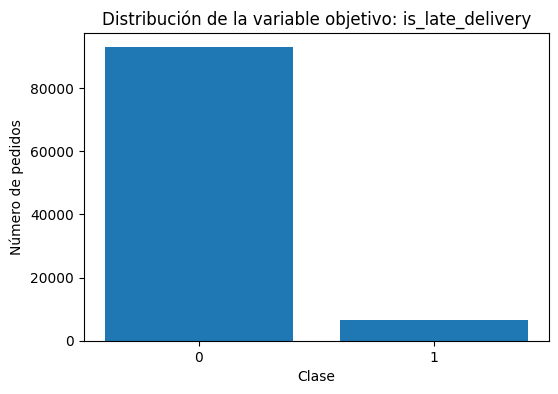

In [17]:
# Distribución de la variable objetivo.
plot_bar(
    distribucion_target['clase'].astype(str),
    distribucion_target['conteo'],
    title='Distribución de la variable objetivo: is_late_delivery',
    xlabel='Clase',
    ylabel='Número de pedidos',
    figsize=(6, 4),
)


### Interpretación de la variable objetivo

La distribución de `is_late_delivery` permite conocer cuántos pedidos fueron entregados tarde y cuántos fueron entregados a tiempo.

Si una de las clases domina demasiado, se debe tener cuidado al evaluar el modelo, ya que la métrica de exactitud o accuracy puede ser engañosa. Por esta razón, en etapas posteriores también deberán considerarse métricas como precision, recall, F1-score y matriz de confusión.

## Estadísticos descriptivos de variables numéricas

En esta sección se revisan medidas descriptivas de las variables numéricas.  
El objetivo es conocer la escala, dispersión, mínimos, máximos y percentiles de variables como pagos, días de entrega, número de ítems, calificaciones, precios y fletes.

Este análisis ayuda a identificar variables con escalas muy diferentes y posibles valores extremos.

In [18]:
# Variables numéricas de tad_pedidos y tad_ventas

numericas_pedidos = tad_pedidos.select_dtypes(include=["int64", "float64"]).columns.tolist()
numericas_ventas = tad_ventas.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Número de variables numéricas en tad_pedidos:", len(numericas_pedidos))
print("Número de variables numéricas en tad_ventas:", len(numericas_ventas))

Número de variables numéricas en tad_pedidos: 22
Número de variables numéricas en tad_ventas: 34


In [19]:
# Estadísticos descriptivos de variables numéricas.
estadisticos = {}
for nombre, df, cols in [
    ('tad_pedidos', tad_pedidos, numericas_pedidos),
    ('tad_ventas',  tad_ventas,  numericas_ventas),
]:
    est = df[cols].describe().T
    est['rango'] = est['max'] - est['min']
    estadisticos[nombre] = est
    print(f'Estadísticos · {nombre}')
    display(est)

estadisticos_pedidos = estadisticos['tad_pedidos']
estadisticos_ventas  = estadisticos['tad_ventas']


Estadísticos · tad_pedidos


,count,mean,std,min,25%,50%,75%,max,rango
customer_zip_code_prefix,"99,441.00","35,137.47","29,797.94","1,003.00","11,347.00","24,416.00","58,900.00","99,990.00","98,987.00"
geo_lat,"99,162.00",-21.19,5.60,-33.69,-23.59,-22.92,-20.14,3.84,37.53
geo_lng,"99,162.00",-46.18,4.05,-72.67,-48.10,-46.63,-43.60,-34.80,37.87
fecha_key,"99,441.00","20,176,017.10","4,879.33","20,160,904.00","20,170,912.00","20,180,118.00","20,180,504.00","20,181,017.00","20,113.00"
anio,"99,441.00","2,017.54",0.51,"2,016.00","2,017.00","2,018.00","2,018.00","2,018.00",2.00
mes,"99,441.00",6.03,3.23,1.00,3.00,6.00,8.00,12.00,11.00
dia,"99,441.00",15.51,8.67,1.00,8.00,15.00,23.00,31.00,30.00
trimestre,"99,441.00",2.36,1.06,1.00,1.00,2.00,3.00,4.00,3.00
dia_semana_num,"99,441.00",2.76,1.97,0.00,1.00,3.00,4.00,6.00,6.00
es_fin_semana,"99,441.00",0.23,0.42,0.00,0.00,0.00,0.00,1.00,1.00


Estadísticos · tad_ventas


,count,mean,std,min,25%,50%,75%,max,rango
order_item_id,"112,650.00",1.20,0.71,1.00,1.00,1.00,1.00,21.00,20.00
customer_zip_code_prefix,"112,650.00","35,119.31","29,866.12","1,003.00","11,310.00","24,340.00","59,028.75","99,990.00","98,987.00"
geo_lat,"112,347.00",-21.24,5.56,-33.69,-23.59,-22.93,-20.18,3.84,37.53
geo_lng,"112,347.00",-46.20,4.03,-72.67,-48.11,-46.63,-43.64,-34.80,37.87
product_name_lenght,"112,650.00",48.81,9.96,5.00,43.00,51.00,57.00,76.00,71.00
product_description_lenght,"112,650.00",785.12,647.88,4.00,348.00,595.00,981.00,"3,992.00","3,988.00"
product_photos_qty,"112,650.00",2.19,1.72,1.00,1.00,1.00,3.00,20.00,19.00
product_weight_g,"112,650.00","2,093.45","3,751.34",0.00,300.00,700.00,"1,800.00","40,425.00","40,425.00"
product_length_cm,"112,650.00",30.15,16.15,7.00,18.00,25.00,38.00,105.00,98.00
product_height_cm,"112,650.00",16.59,13.44,2.00,8.00,13.00,20.00,105.00,103.00


### Variables numéricas relevantes para revisión

Para evitar saturar el análisis, se seleccionan variables numéricas relevantes para el problema logístico y comercial.

En `tad_pedidos` se revisan variables relacionadas con pagos, reseñas, días de entrega y número de ítems.

En `tad_ventas` se revisan variables relacionadas con precio, flete, valor por ítem, dimensiones del producto, calificación y tiempos de entrega.

In [20]:
# Variables relevantes para análisis descriptivo

vars_num_pedidos_relevantes = [
    "payment_value",
    "payment_installments",
    "review_score",
    "delivery_days_real",
    "delivery_days_estimated",
    "delivery_delay_days",
    "num_items"
]

vars_num_ventas_relevantes = [
    "price",
    "freight_value",
    "total_item_value",
    "payment_value_item",
    "product_weight_g",
    "product_volume_cm3",
    "review_score",
    "delivery_days_real",
    "delivery_days_estimated",
    "delivery_delay_days"
]

vars_num_pedidos_relevantes = [
    col for col in vars_num_pedidos_relevantes if col in tad_pedidos.columns
]

vars_num_ventas_relevantes = [
    col for col in vars_num_ventas_relevantes if col in tad_ventas.columns
]

display(tad_pedidos[vars_num_pedidos_relevantes].describe().T)
display(tad_ventas[vars_num_ventas_relevantes].describe().T)

,count,mean,std,min,25%,50%,75%,max
payment_value,"99,440.00",160.99,221.95,0.00,62.01,105.29,176.97,"13,664.08"
payment_installments,"99,440.00",2.93,2.72,0.00,1.00,2.00,4.00,24.00
review_score,"98,673.00",4.09,1.35,1.00,4.00,5.00,5.00,5.00
delivery_days_real,"96,476.00",12.09,9.55,0.00,6.00,10.00,15.00,209.00
delivery_days_estimated,"99,441.00",23.40,8.83,1.00,18.00,23.00,28.00,155.00
delivery_delay_days,"99,441.00",-11.52,10.23,-147.00,-17.00,-12.00,-7.00,188.00
num_items,"99,441.00",1.13,0.55,0.00,1.00,1.00,1.00,21.00


,count,mean,std,min,25%,50%,75%,max
price,"112,650.00",120.65,183.63,0.85,39.90,74.99,134.90,"6,735.00"
freight_value,"112,650.00",19.99,15.81,0.00,13.08,16.26,21.15,409.68
total_item_value,"112,650.00",140.64,190.72,6.08,55.22,92.32,157.94,"6,929.31"
payment_value_item,"112,650.00",140.67,190.16,0.00,55.69,92.57,157.91,"6,929.31"
product_weight_g,"112,650.00","2,093.45","3,751.34",0.00,300.00,700.00,"1,800.00","40,425.00"
product_volume_cm3,"112,650.00","15,242.31","23,416.91",168.00,"2,852.00","6,480.00","18,373.25","296,208.00"
review_score,"111,708.00",4.03,1.39,1.00,4.00,5.00,5.00,5.00
delivery_days_real,"110,196.00",12.01,9.45,0.00,6.00,10.00,15.00,209.00
delivery_days_estimated,"112,650.00",23.47,8.88,2.00,18.00,23.00,28.00,155.00
delivery_delay_days,"112,650.00",-11.77,10.20,-147.00,-17.00,-12.00,-7.00,188.00


## Análisis de valores atípicos

Se revisan posibles valores atípicos en variables numéricas utilizando el método del rango intercuartílico, conocido como IQR.

Un valor atípico no necesariamente representa un error. En este proyecto, pueden existir pedidos con tiempos de entrega altos, pagos elevados o fletes costosos debido a condiciones reales de la operación. Sin embargo, es importante identificarlos porque pueden afectar modelos sensibles a escala.

In [21]:
def detectar_atipicos_iqr(df, columnas):
    resultados = []

    for col in columnas:
        serie = df[col].dropna()

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        num_atipicos = ((serie < limite_inferior) | (serie > limite_superior)).sum()
        porcentaje_atipicos = num_atipicos / len(df) * 100

        resultados.append({
            "variable": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inferior": limite_inferior,
            "limite_superior": limite_superior,
            "num_atipicos": num_atipicos,
            "porcentaje_atipicos": round(porcentaje_atipicos, 2)
        })

    return pd.DataFrame(resultados).sort_values("porcentaje_atipicos", ascending=False)

In [22]:
atipicos_pedidos = detectar_atipicos_iqr(tad_pedidos, vars_num_pedidos_relevantes)
atipicos_ventas = detectar_atipicos_iqr(tad_ventas, vars_num_ventas_relevantes)

print("Valores atípicos en tad_pedidos")
display(atipicos_pedidos)

print("Valores atípicos en tad_ventas")
display(atipicos_ventas)

Valores atípicos en tad_pedidos


,variable,q1,q3,iqr,limite_inferior,limite_superior,num_atipicos,porcentaje_atipicos
2,review_score,4.00,5.00,1.00,2.50,6.50,14449,14.53
6,num_items,1.00,1.00,0.00,1.00,1.00,10578,10.64
0,payment_value,62.01,176.97,114.96,-110.43,349.41,7866,7.91
1,payment_installments,1.00,4.00,3.00,-3.50,8.50,6300,6.34
3,delivery_days_real,6.00,15.00,9.00,-7.50,28.50,5025,5.05
5,delivery_delay_days,-17.00,-7.00,10.00,-32.00,8.00,4301,4.33
4,delivery_days_estimated,18.00,28.00,10.00,3.00,43.00,2464,2.48


Valores atípicos en tad_ventas


,variable,q1,q3,iqr,limite_inferior,limite_superior,num_atipicos,porcentaje_atipicos
6,review_score,4.00,5.00,1.00,2.50,6.50,17930,15.92
4,product_weight_g,300.00,"1,800.00","1,500.00","-1,950.00","4,050.00",15807,14.03
1,freight_value,13.08,21.15,8.07,0.98,33.25,12134,10.77
5,product_volume_cm3,"2,852.00","18,373.25","15,521.25","-20,429.88","41,655.12",10004,8.88
0,price,39.90,134.90,95.00,-102.60,277.40,8427,7.48
2,total_item_value,55.22,157.94,102.72,-98.86,312.01,8253,7.33
3,payment_value_item,55.69,157.91,102.22,-97.63,311.24,8241,7.32
7,delivery_days_real,6.00,15.00,9.00,-7.50,28.50,5560,4.94
9,delivery_delay_days,-17.00,-7.00,10.00,-32.00,8.00,4926,4.37
8,delivery_days_estimated,18.00,28.00,10.00,3.00,43.00,2885,2.56


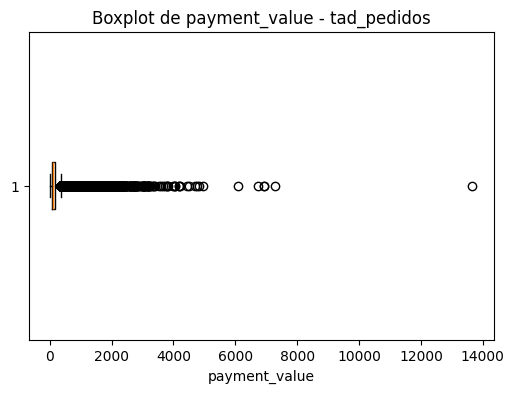

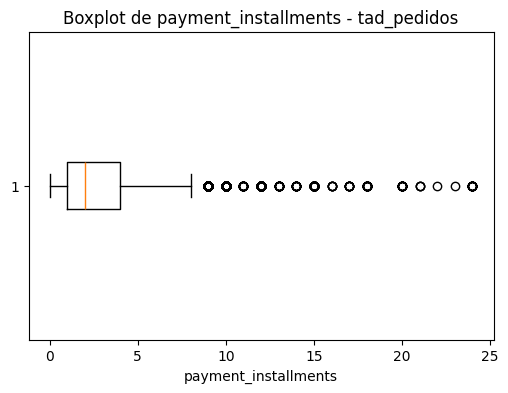

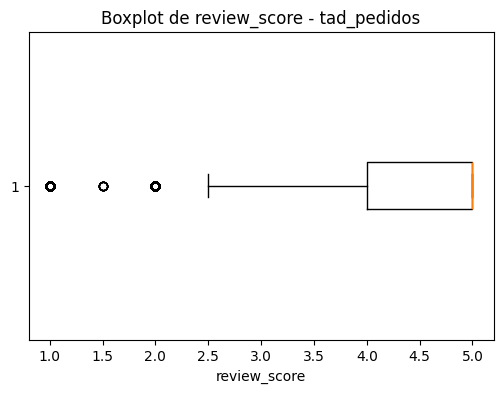

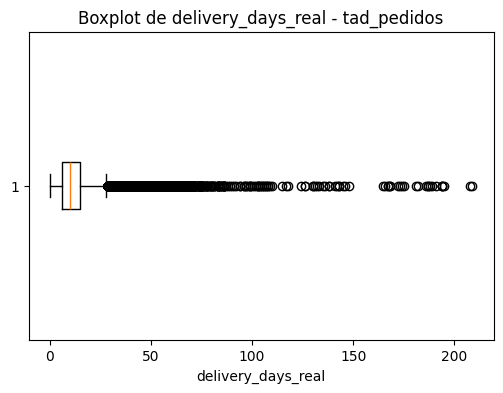

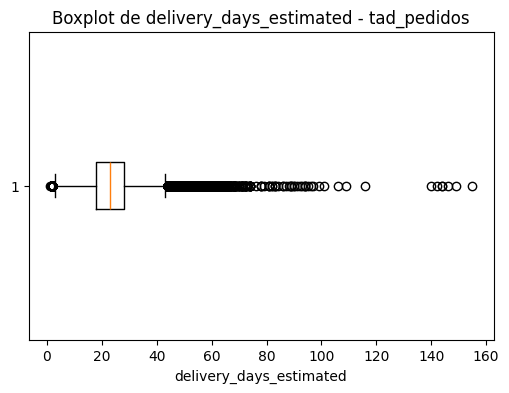

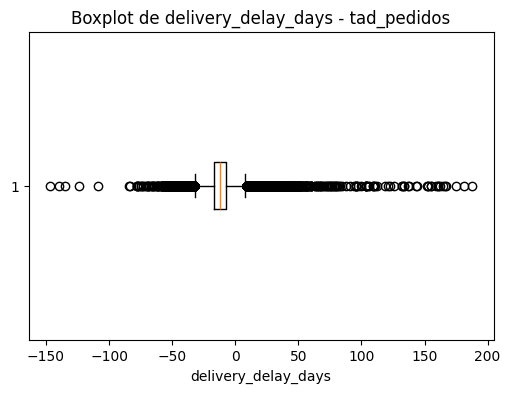

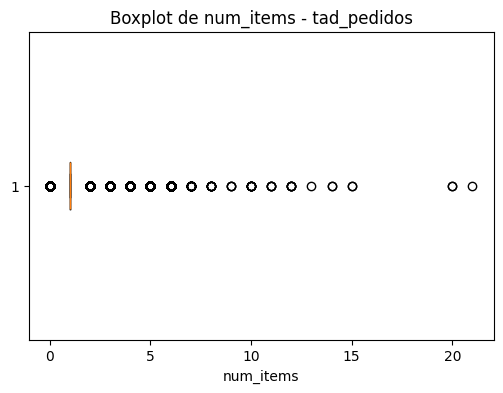

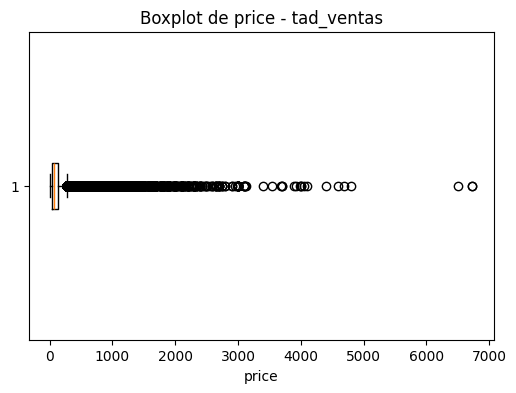

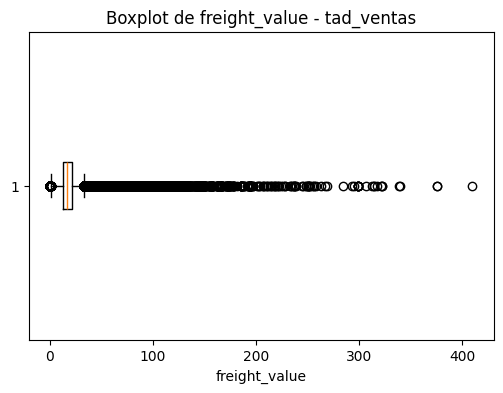

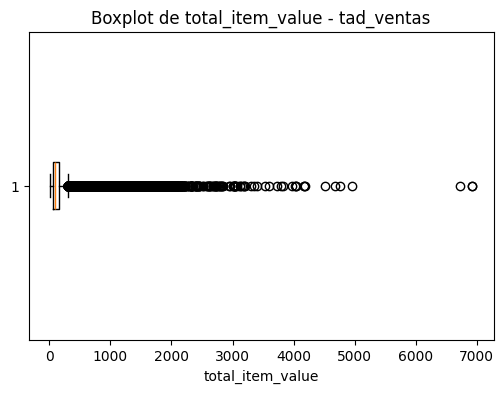

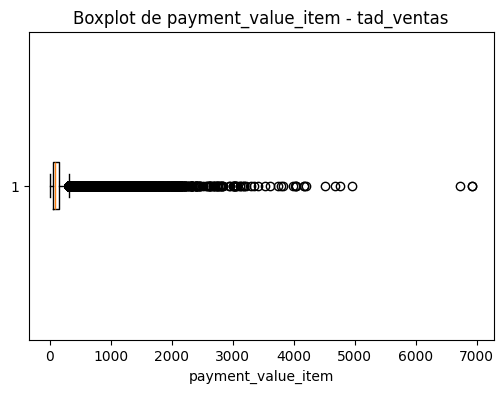

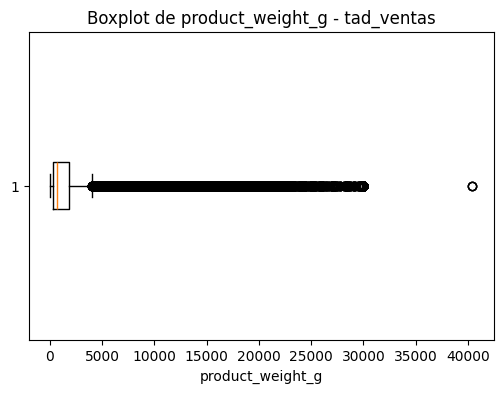

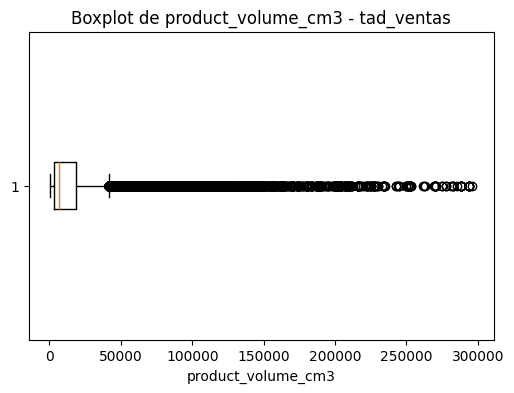

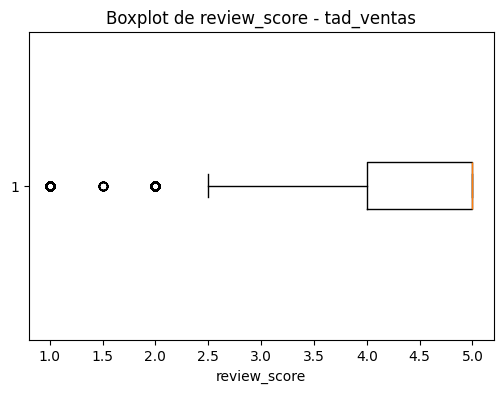

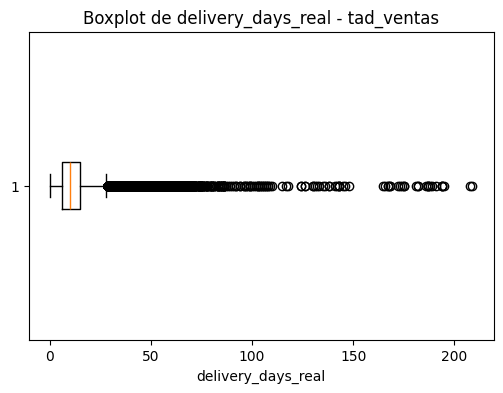

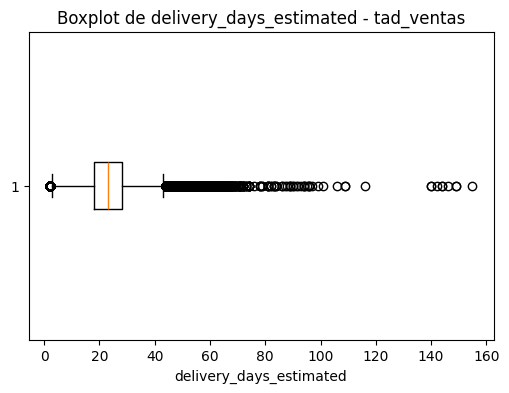

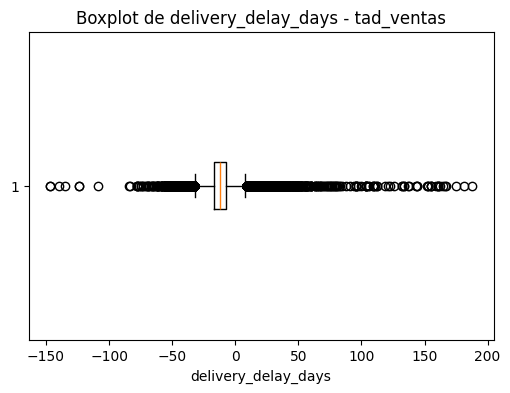

In [23]:
# Boxplots para variables numéricas relevantes de ambas sabanas.
for nombre, df, cols in [
    ('tad_pedidos', tad_pedidos, vars_num_pedidos_relevantes),
    ('tad_ventas',  tad_ventas,  vars_num_ventas_relevantes),
]:
    for col in cols:
        plt.figure(figsize=(6, 4))
        plt.boxplot(df[col].dropna(), vert=False)
        plt.title(f'Boxplot de {col} - {nombre}')
        plt.xlabel(col)
        plt.show()


### Interpretación de valores atípicos

La presencia de valores atípicos debe interpretarse dentro del contexto del negocio.  
En una cadena de suministro, valores altos en flete, precio, pago o días de entrega pueden representar casos reales y no necesariamente errores.

Estos valores deberán considerarse posteriormente al seleccionar técnicas de escalamiento o al elegir modelos. Para modelos basados en distancias, como KNN o K-medias, los valores atípicos pueden tener mayor impacto.

## Relación entre variables categóricas y retraso

En esta sección se analiza la relación entre algunas variables categóricas y la variable objetivo `is_late_delivery`.

El objetivo es observar si ciertos grupos presentan una tasa de retraso mayor.  
Esto no implica causalidad, pero ayuda a identificar variables potencialmente útiles para el modelado supervisado.

In [24]:
def tasa_retraso_por_categoria(df, columna, target="is_late_delivery", min_registros=100):
    resumen = (
        df.groupby(columna)
        .agg(
            total_pedidos=(target, "count"),
            pedidos_tarde=(target, "sum"),
            tasa_retraso=(target, "mean")
        )
        .reset_index()
    )

    resumen["tasa_retraso"] = (resumen["tasa_retraso"] * 100).round(2)
    resumen = resumen[resumen["total_pedidos"] >= min_registros]
    resumen = resumen.sort_values("tasa_retraso", ascending=False)

    return resumen

In [25]:
variables_categoricas_target = [
    "customer_state",
    "payment_type",
    "order_status",
    "dia_semana_nombre",
    "mes",
    "trimestre",
    "es_fin_semana"
]

variables_categoricas_target = [
    col for col in variables_categoricas_target if col in tad_pedidos.columns
]

for col in variables_categoricas_target:
    print(f"Tasa de retraso por {col}")
    display(tasa_retraso_por_categoria(tad_pedidos, col, min_registros=100))

Tasa de retraso por customer_state


,customer_state,total_pedidos,pedidos_tarde,tasa_retraso
1,AL,413,85,20.58
9,MA,747,125,16.73
24,SE,350,51,14.57
16,PI,495,66,13.33
5,CE,1336,176,13.17
4,BA,3380,396,11.72
18,RJ,12852,1495,11.63
13,PA,975,106,10.87
7,ES,2033,214,10.53
14,PB,536,54,10.07


Tasa de retraso por payment_type


,payment_type,total_pedidos,pedidos_tarde,tasa_retraso
0,boleto,19784,1405,7.10
1,credit_card,76132,4941,6.49
4,voucher,1994,109,5.47
2,debit_card,1527,79,5.17


Tasa de retraso por order_status


...

,mes,total_pedidos,pedidos_tarde,tasa_retraso
2,3,9893,1444,14.60
10,11,7544,904,11.98
1,2,8508,976,11.47
11,12,5674,411,7.24
0,1,8069,425,5.27
4,5,10573,549,5.19
3,4,9343,457,4.89
7,8,10843,515,4.75
8,9,4305,183,4.25
9,10,4959,189,3.81


Tasa de retraso por trimestre


,trimestre,total_pedidos,pedidos_tarde,tasa_retraso
0,1,26470,2845,10.75
3,4,18177,1504,8.27
1,2,29328,1172,4.00
2,3,25466,1014,3.98


Tasa de retraso por es_fin_semana


,es_fin_semana,total_pedidos,pedidos_tarde,tasa_retraso
0,0,76594,5115,6.68
1,1,22847,1420,6.22


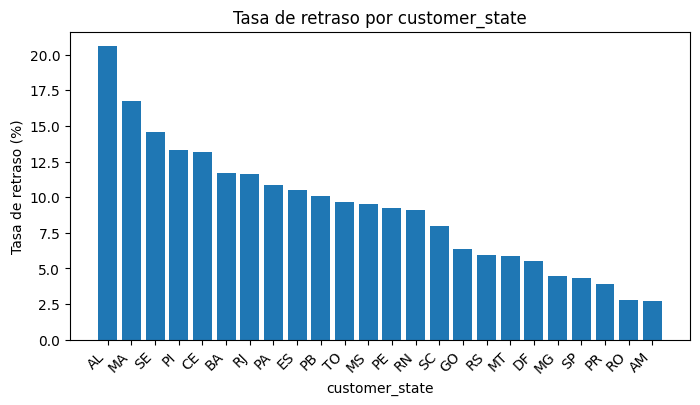

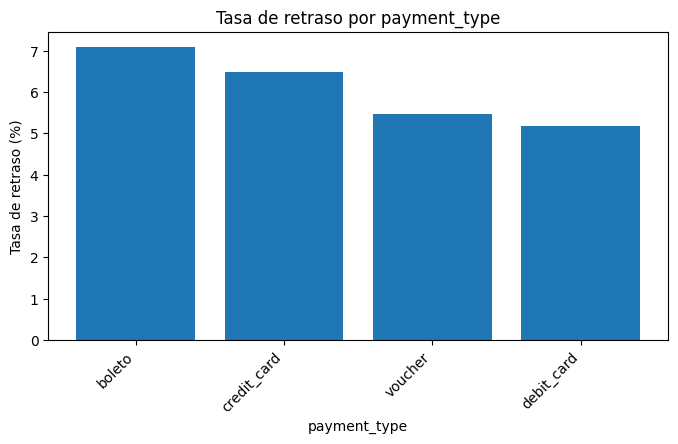

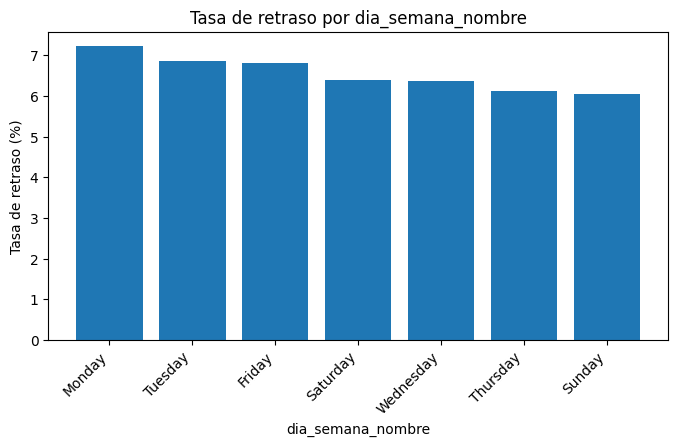

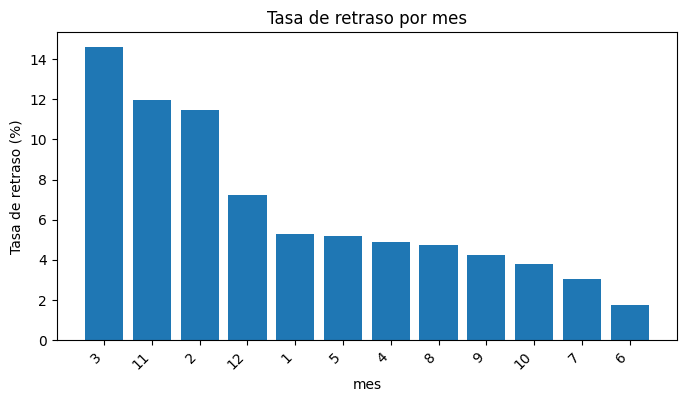

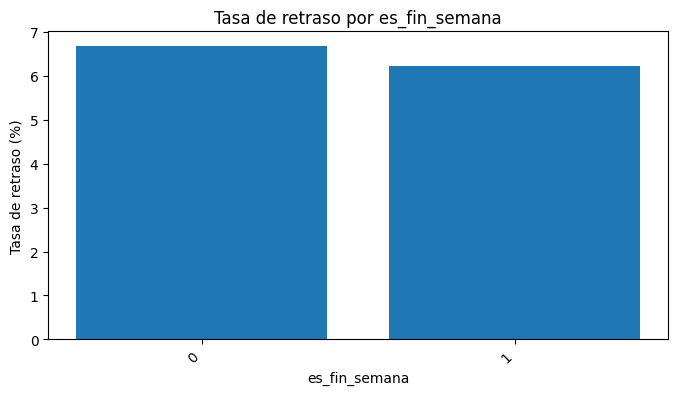

In [26]:
# Tasa de retraso por variables categóricas relevantes.
variables_graficar = [
    'customer_state', 'payment_type', 'dia_semana_nombre', 'mes', 'es_fin_semana'
]
variables_graficar = [c for c in variables_graficar if c in tad_pedidos.columns]

for col in variables_graficar:
    resumen = tasa_retraso_por_categoria(tad_pedidos, col, min_registros=100)
    plot_bar(
        resumen[col], resumen['tasa_retraso'],
        title=f'Tasa de retraso por {col}',
        xlabel=col, ylabel='Tasa de retraso (%)',
        figsize=(8, 4), rotation=45,
    )


### Interpretación de variables categóricas

Este análisis permite identificar si existen estados, métodos de pago o periodos con mayor proporción de entregas tardías.  
Las variables que muestran diferencias claras entre grupos pueden considerarse candidatas para etapas posteriores de modelado, siempre que no representen fuga de información.

## Relación entre variables numéricas y retraso

En esta sección se comparan variables numéricas según la clase de `is_late_delivery`.

El objetivo es observar si los pedidos tardíos y no tardíos presentan diferencias en variables como pago, número de ítems, días estimados de entrega o calificación.

In [27]:
# Comparación de medias y medianas por clase objetivo

comparacion_numericas_target = (
    tad_pedidos
    .groupby("is_late_delivery")[vars_num_pedidos_relevantes]
    .agg(["mean", "median", "std", "min", "max"])
)

display(comparacion_numericas_target)

payment_value                                \
                          mean median    std   min       max   
is_late_delivery                                               
0                       159.92 104.79 220.52  0.00 13,664.08   
1                       176.14 114.09 240.90 14.29  6,922.21   

                 payment_installments                        review_score  \
                                 mean median  std  min   max         mean   
is_late_delivery                                                            
0                                2.92   2.00 2.71 0.00 24.00         4.21   
1                                3.05   2.00 2.80 1.00 24.00         2.27   

                                       delivery_days_real                    \
                 median  std  min  max               mean median   std  min   
is_late_delivery                                                              
0                  5.00 1.23 1.00 5.00              10.54   9.00  6.32 0.00   
1                  1.00 1.57 1.00 5.00              33.49  31.00 17.48 3.00   

                        delivery_days_estimated                       \
                    max                    mean median  std min  max   
is_late_delivery                                                       
0                 70.00                   23.48  23.00 8.91   1  155   
1                209.00                   22.29  22.00 7.56   2   69   

                 delivery_delay_days                             num_items  \
                                mean median   std     min    max      mean   
is_late_delivery                                                             
0                             -13.08 -13.00  7.75 -147.00   0.00      1.13   
1                              10.62   7.00 14.64    1.00 188.00      1.11   

                                      
                 median  std min max  
is_late_delivery                      
0                  1.00 0.55   0  20  
1                  1.00 0.51   1  21

/var/folders/ng/z8yp5nhd1dq5qx7s8z5dxt540000gn/T/ipykernel_12157/1387878630.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([datos_0, datos_1], labels=["No tarde", "Tarde"])


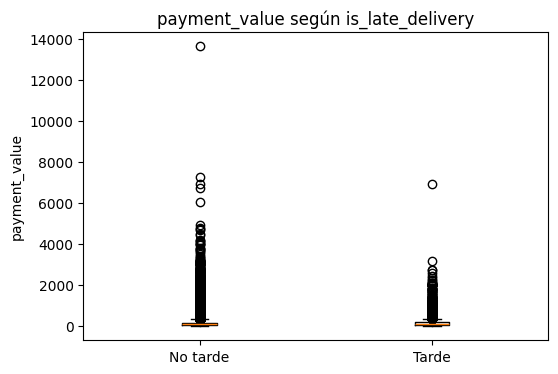

/var/folders/ng/z8yp5nhd1dq5qx7s8z5dxt540000gn/T/ipykernel_12157/1387878630.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([datos_0, datos_1], labels=["No tarde", "Tarde"])


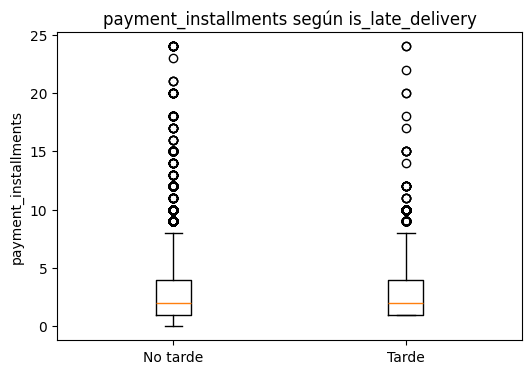

/var/folders/ng/z8yp5nhd1dq5qx7s8z5dxt540000gn/T/ipykernel_12157/1387878630.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([datos_0, datos_1], labels=["No tarde", "Tarde"])


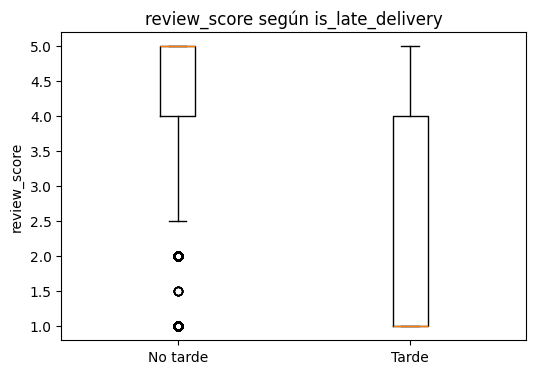

/var/folders/ng/z8yp5nhd1dq5qx7s8z5dxt540000gn/T/ipykernel_12157/1387878630.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([datos_0, datos_1], labels=["No tarde", "Tarde"])


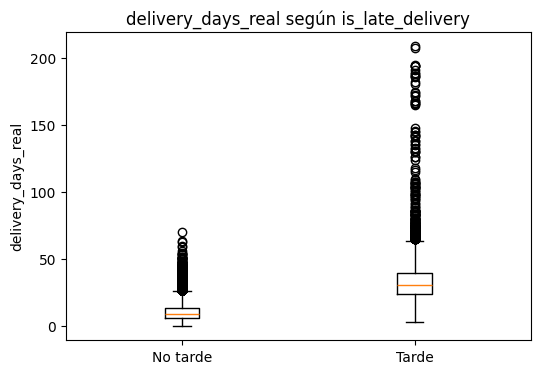

/var/folders/ng/z8yp5nhd1dq5qx7s8z5dxt540000gn/T/ipykernel_12157/1387878630.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([datos_0, datos_1], labels=["No tarde", "Tarde"])


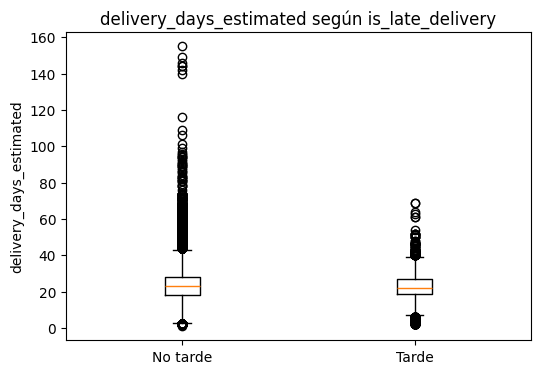

/var/folders/ng/z8yp5nhd1dq5qx7s8z5dxt540000gn/T/ipykernel_12157/1387878630.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([datos_0, datos_1], labels=["No tarde", "Tarde"])


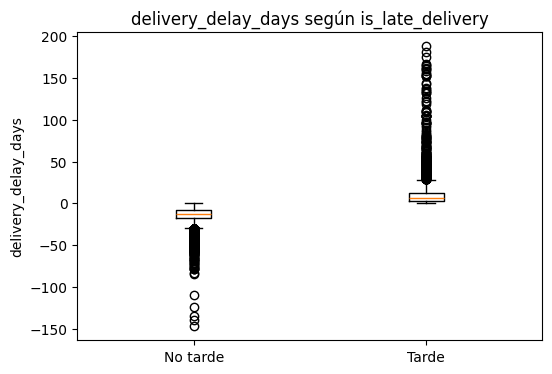

/var/folders/ng/z8yp5nhd1dq5qx7s8z5dxt540000gn/T/ipykernel_12157/1387878630.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([datos_0, datos_1], labels=["No tarde", "Tarde"])


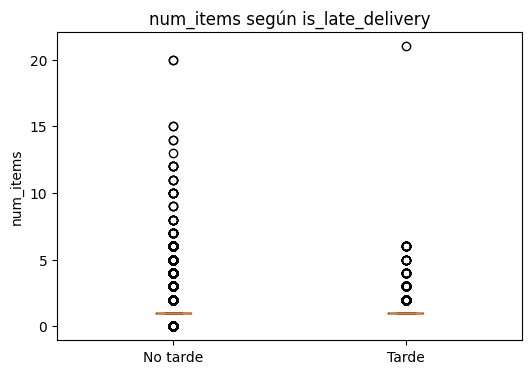

In [28]:
# Boxplots por clase para variables numéricas relevantes

for col in vars_num_pedidos_relevantes:
    datos_0 = tad_pedidos[tad_pedidos["is_late_delivery"] == 0][col].dropna()
    datos_1 = tad_pedidos[tad_pedidos["is_late_delivery"] == 1][col].dropna()

    plt.figure(figsize=(6, 4))
    plt.boxplot([datos_0, datos_1], labels=["No tarde", "Tarde"])
    plt.title(f"{col} según is_late_delivery")
    plt.ylabel(col)
    plt.show()

### Interpretación de variables numéricas

Si una variable presenta diferencias importantes entre pedidos tardíos y no tardíos, puede ser útil para el modelo supervisado.  
Sin embargo, algunas variables deben revisarse por fuga de información, especialmente aquellas que se conocen después de que el pedido fue entregado.

## Correlación entre variables numéricas

Se calcula la matriz de correlación para identificar relaciones lineales entre variables numéricas.

Este análisis ayuda a detectar posibles problemas de multicolinealidad, especialmente si se utilizan modelos como regresión logística.

In [29]:
# Variables numéricas candidatas para correlación en tad_pedidos

cols_corr_pedidos = [
    "payment_value",
    "payment_installments",
    "review_score",
    "delivery_days_real",
    "delivery_days_estimated",
    "delivery_delay_days",
    "num_items",
    "is_late_delivery"
]

cols_corr_pedidos = [col for col in cols_corr_pedidos if col in tad_pedidos.columns]

correlacion_pedidos = tad_pedidos[cols_corr_pedidos].corr(numeric_only=True)

display(correlacion_pedidos)

,payment_value,payment_installments,review_score,delivery_days_real,delivery_days_estimated,delivery_delay_days,num_items,is_late_delivery
payment_value,1.00,0.32,-0.05,0.07,0.09,-0.01,0.18,0.02
payment_installments,0.32,1.00,-0.03,0.05,0.09,-0.03,0.07,0.01
review_score,-0.05,-0.03,1.00,-0.33,-0.05,-0.30,-0.08,-0.35
delivery_days_real,0.07,0.05,-0.33,1.00,0.38,0.61,-0.02,0.60
delivery_days_estimated,0.09,0.09,-0.05,0.38,1.00,-0.47,0.02,-0.03
delivery_delay_days,-0.01,-0.03,-0.30,0.61,-0.47,1.00,-0.05,0.57
num_items,0.18,0.07,-0.08,-0.02,0.02,-0.05,1.00,-0.01
is_late_delivery,0.02,0.01,-0.35,0.60,-0.03,0.57,-0.01,1.00


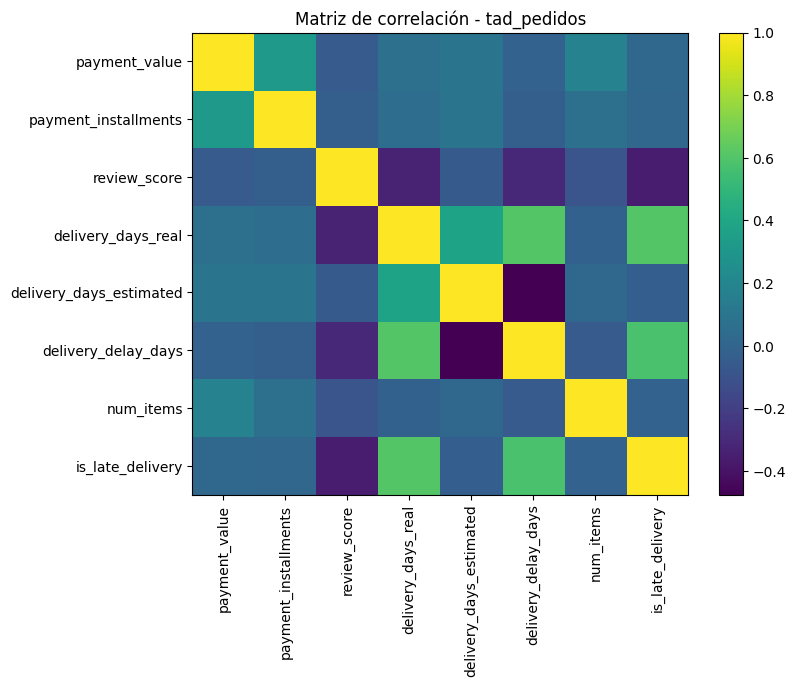

In [30]:
# Mapa de calor sencillo con matplotlib

plt.figure(figsize=(8, 6))
plt.imshow(correlacion_pedidos, aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlacion_pedidos.columns)), correlacion_pedidos.columns, rotation=90)
plt.yticks(range(len(correlacion_pedidos.index)), correlacion_pedidos.index)
plt.title("Matriz de correlación - tad_pedidos")
plt.show()

In [31]:
def pares_correlacion_alta(corr_matrix, umbral=0.80):
    pares = []

    columnas = corr_matrix.columns

    for i in range(len(columnas)):
        for j in range(i + 1, len(columnas)):
            corr = corr_matrix.iloc[i, j]
            if abs(corr) >= umbral:
                pares.append({
                    "variable_1": columnas[i],
                    "variable_2": columnas[j],
                    "correlacion": round(corr, 4)
                })

    resultado = pd.DataFrame(pares)

    if resultado.empty:
        print(f"No se encontraron pares de variables con correlación absoluta >= {umbral}.")
        return resultado

    return resultado.sort_values("correlacion", ascending=False)

pares_corr_alta = pares_correlacion_alta(correlacion_pedidos, umbral=0.80)
display(pares_corr_alta)

No se encontraron pares de variables con correlación absoluta >= 0.8.


""


### Interpretación de correlación

La correlación permite identificar variables que se mueven de forma similar.  
Si dos variables presentan correlación muy alta, podría no ser conveniente utilizar ambas en ciertos modelos, ya que pueden aportar información redundante.

En modelos como árboles de decisión, la multicolinealidad suele ser menos problemática, pero en modelos lineales o logísticos puede afectar la estabilidad de los coeficientes.

## Revisión de fuga de información

La fuga de información ocurre cuando se utilizan como variables predictoras datos que no estarían disponibles al momento de hacer la predicción.

Para este proyecto, si el objetivo es anticipar si un pedido se entregará tarde, no deben usarse variables que se conocen después de la entrega, como los días reales de entrega o la calificación del cliente.

In [32]:
# Variables con posible fuga de información para un modelo que busca anticipar retrasos

variables_fuga_informacion = [
    "order_delivered_customer_date",
    "delivery_days_real",
    "delivery_delay_days",
    "review_score",
    "is_bad_review",
    "is_good_review",
    "is_late_delivery"
]

variables_fuga_presentes = [
    col for col in variables_fuga_informacion if col in tad_pedidos.columns
]

reporte_fuga = pd.DataFrame({
    "variable": variables_fuga_presentes,
    "motivo": [
        "Fecha conocida después de la entrega" if col == "order_delivered_customer_date" else
        "Se calcula cuando el pedido ya fue entregado" if col == "delivery_days_real" else
        "Depende de la diferencia entre entrega real y estimada" if col == "delivery_delay_days" else
        "La reseña ocurre después de la experiencia de entrega" if col == "review_score" else
        "Depende de la calificación posterior del cliente" if col in ["is_bad_review", "is_good_review"] else
        "Es la variable objetivo, no debe usarse como entrada"
        for col in variables_fuga_presentes
    ]
})

display(reporte_fuga)

,variable,motivo
0,order_delivered_customer_date,Fecha conocida después de la entrega
1,delivery_days_real,Se calcula cuando el pedido ya fue entregado
2,delivery_delay_days,Depende de la diferencia entre entrega real y ...
3,review_score,La reseña ocurre después de la experiencia de ...
4,is_bad_review,Depende de la calificación posterior del cliente
5,is_good_review,Depende de la calificación posterior del cliente
6,is_late_delivery,"Es la variable objetivo, no debe usarse como e..."


### Interpretación de fuga de información

Las variables identificadas con posible fuga de información pueden ser útiles para análisis descriptivo y dashboard, pero no deben utilizarse como variables predictoras si el modelo pretende anticipar un retraso antes de que ocurra.

Por ejemplo, `delivery_delay_days` describe el retraso real, pero solo puede calcularse después de conocer la fecha real de entrega. Por ello, no sería válido usarla como entrada del modelo supervisado.

## Análisis preliminar para clustering de sellers

Además del modelo supervisado, el proyecto contempla una etapa de segmentación de sellers.  
Para ello, se requiere construir una tabla agregada a nivel vendedor a partir de `tad_ventas`.

En esta sección no se ejecuta todavía el algoritmo de clustering.  
Únicamente se prepara y explora la tabla base para identificar variables útiles.

In [33]:
# Construcción de tabla agregada por seller

seller_agg = (
    tad_ventas
    .groupby("seller_id")
    .agg(
        total_items_vendidos=("order_item_id", "count"),
        ordenes_asociadas=("order_id", "nunique"),
        ingreso_total=("payment_value_item", "sum"),
        precio_promedio=("price", "mean"),
        flete_promedio=("freight_value", "mean"),
        valor_item_promedio=("total_item_value", "mean"),
        retraso_promedio=("delivery_delay_days", "mean"),
        dias_estimados_promedio=("delivery_days_estimated", "mean"),
        calificacion_promedio=("review_score", "mean"),
        porcentaje_entregas_tarde=("is_late_delivery", "mean"),
        porcentaje_malas_resenas=("is_bad_review", "mean")
    )
    .reset_index()
)

seller_agg["porcentaje_entregas_tarde"] = seller_agg["porcentaje_entregas_tarde"] * 100
seller_agg["porcentaje_malas_resenas"] = seller_agg["porcentaje_malas_resenas"] * 100

display(seller_agg.head())
print("Dimensiones de seller_agg:", seller_agg.shape)

,seller_id,total_items_vendidos,ordenes_asociadas,ingreso_total,precio_promedio,flete_promedio,valor_item_promedio,retraso_promedio,dias_estimados_promedio,calificacion_promedio,porcentaje_entregas_tarde,porcentaje_malas_resenas
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,"2,748.06",895.00,21.02,916.02,-16.33,26.00,3.67,0.00,33.33
1,001cca7ae9ae17fb1caed9dfb1094831,239,200,"33,889.89",104.94,37.05,141.98,-12.94,25.30,3.90,5.02,18.83
2,001e6ad469a905060d959994f1b41e4f,1,1,267.94,250.00,17.94,267.94,0.00,12.00,1.00,0.00,100.00
3,002100f778ceb8431b7a1020ff7ab48f,55,51,"2,073.04",22.45,14.43,36.88,-8.04,23.25,3.98,16.36,14.55
4,003554e2dce176b5555353e4f3555ac8,1,1,139.38,120.00,19.38,139.38,-27.00,30.00,5.00,0.00,0.00


Dimensiones de seller_agg: (3095, 12)


In [34]:
# Revisión de nulos en seller_agg

estructura_seller = resumen_estructura(seller_agg, "seller_agg")
display(estructura_seller)

,tabla,columna,tipo_dato,valores_no_nulos,valores_nulos,porcentaje_nulos,valores_unicos
0,seller_agg,seller_id,str,3095,0,0.00,3095
1,seller_agg,total_items_vendidos,int64,3095,0,0.00,257
2,seller_agg,ordenes_asociadas,int64,3095,0,0.00,251
3,seller_agg,ingreso_total,float64,3095,0,0.00,3082
4,seller_agg,precio_promedio,float64,3095,0,0.00,2686
5,seller_agg,flete_promedio,float64,3095,0,0.00,2868
6,seller_agg,valor_item_promedio,float64,3095,0,0.00,3075
7,seller_agg,retraso_promedio,float64,3095,0,0.00,1487
8,seller_agg,dias_estimados_promedio,float64,3095,0,0.00,1506
9,seller_agg,calificacion_promedio,float64,3090,5,0.16,832


In [35]:
# Estadísticos descriptivos para seller_agg

vars_seller_clustering = [
    "total_items_vendidos",
    "ordenes_asociadas",
    "ingreso_total",
    "precio_promedio",
    "flete_promedio",
    "valor_item_promedio",
    "retraso_promedio",
    "dias_estimados_promedio",
    "calificacion_promedio",
    "porcentaje_entregas_tarde",
    "porcentaje_malas_resenas"
]

vars_seller_clustering = [
    col for col in vars_seller_clustering if col in seller_agg.columns
]

display(seller_agg[vars_seller_clustering].describe().T)

,count,mean,std,min,25%,50%,75%,max
total_items_vendidos,"3,095.00",36.40,119.19,1.00,2.00,8.00,24.00,"2,033.00"
ordenes_asociadas,"3,095.00",32.31,105.14,1.00,2.00,6.00,21.50,"1,854.00"
ingreso_total,"3,095.00","5,119.96","15,917.28",12.22,270.40,996.84,"3,979.75","250,012.51"
precio_promedio,"3,095.00",176.33,322.15,3.50,52.18,95.47,173.99,"6,729.00"
flete_promedio,"3,095.00",23.38,18.96,1.20,14.74,18.23,24.37,308.34
valor_item_promedio,"3,095.00",199.71,333.06,12.22,69.56,114.71,201.49,"6,922.21"
retraso_promedio,"3,095.00",-11.42,7.89,-61.00,-14.97,-11.45,-8.23,167.00
dias_estimados_promedio,"3,095.00",23.52,7.93,2.00,19.22,23.00,26.75,144.00
calificacion_promedio,"3,090.00",3.97,0.97,1.00,3.71,4.17,4.60,5.00
porcentaje_entregas_tarde,"3,095.00",6.22,14.46,0.00,0.00,0.00,6.96,100.00


In [36]:
# Revisión de atípicos en variables agregadas de sellers

atipicos_seller = detectar_atipicos_iqr(seller_agg, vars_seller_clustering)
display(atipicos_seller)

,variable,q1,q3,iqr,limite_inferior,limite_superior,num_atipicos,porcentaje_atipicos
1,ordenes_asociadas,2.00,21.50,19.50,-27.25,50.75,421,13.60
0,total_items_vendidos,2.00,24.00,22.00,-31.00,57.00,416,13.44
2,ingreso_total,270.40,"3,979.75","3,709.35","-5,293.61","9,543.77",365,11.79
4,flete_promedio,14.74,24.37,9.63,0.30,38.81,303,9.79
3,precio_promedio,52.18,173.99,121.81,-130.53,356.71,298,9.63
5,valor_item_promedio,69.56,201.49,131.93,-128.33,399.38,296,9.56
9,porcentaje_entregas_tarde,0.00,6.96,6.96,-10.44,17.40,286,9.24
8,calificacion_promedio,3.71,4.60,0.89,2.39,5.93,246,7.95
10,porcentaje_malas_resenas,0.00,23.08,23.08,-34.62,57.69,246,7.95
6,retraso_promedio,-14.97,-8.23,6.74,-25.09,1.89,167,5.40


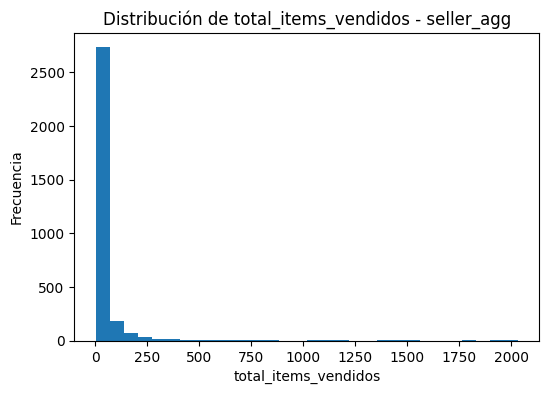

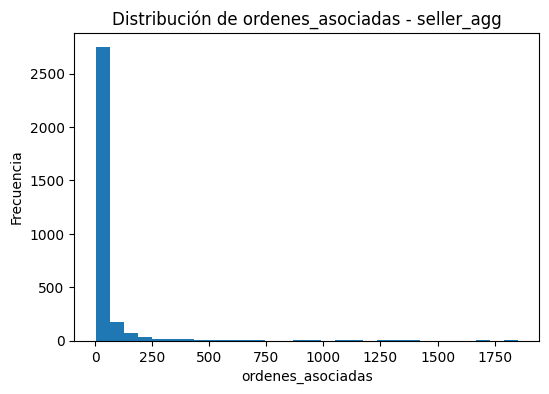

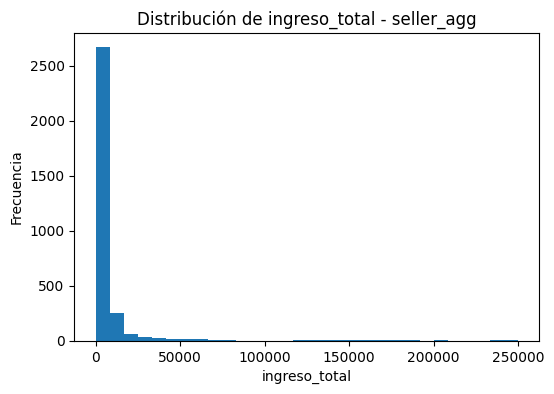

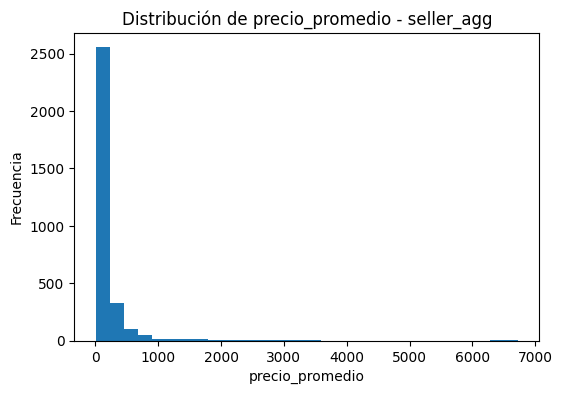

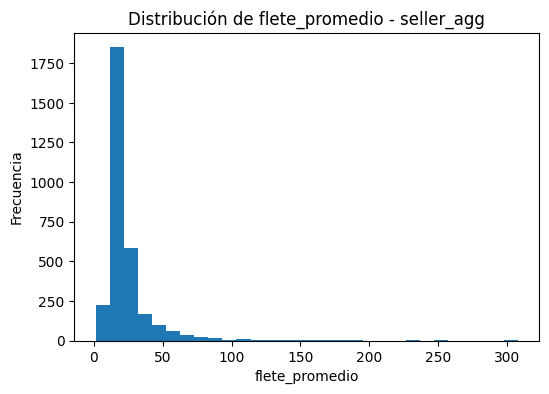

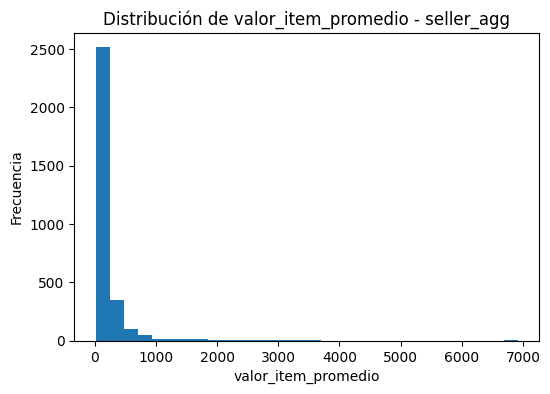

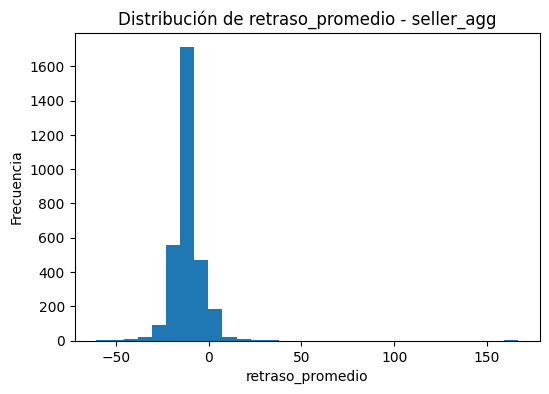

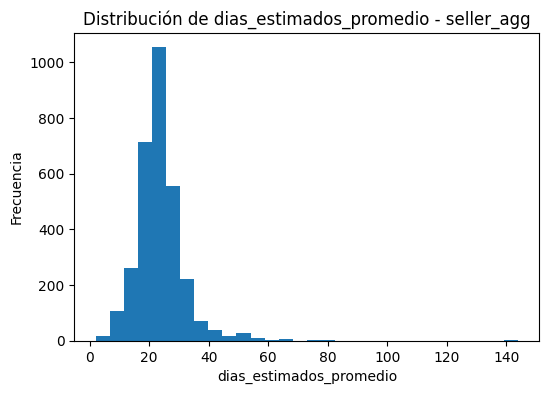

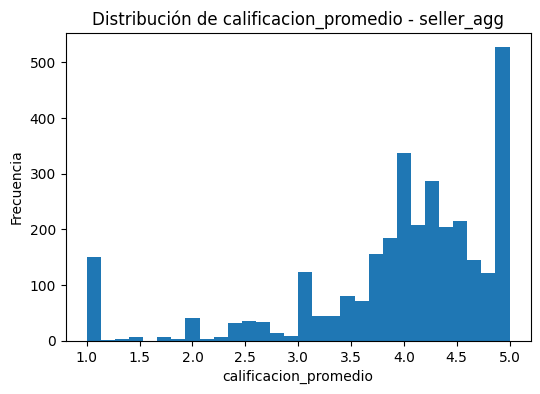

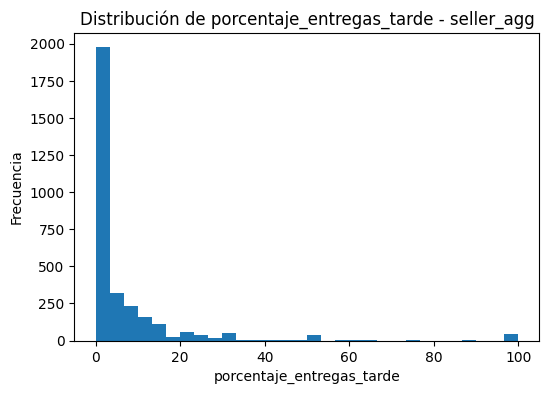

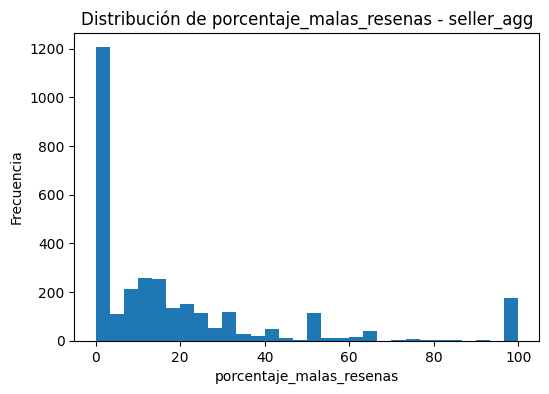

In [37]:
# Distribución de algunas variables agregadas

for col in vars_seller_clustering:
    plt.figure(figsize=(6, 4))
    plt.hist(seller_agg[col].dropna(), bins=30)
    plt.title(f"Distribución de {col} - seller_agg")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

### Interpretación preliminar para clustering

La tabla `seller_agg` resume el comportamiento de cada vendedor a partir de variables comerciales, logísticas y de satisfacción.

Estas variables permitirán posteriormente aplicar un algoritmo de clustering para identificar grupos de sellers con características similares.  
Antes de aplicar K-medias, será necesario revisar valores nulos, atípicos y escalamiento, ya que K-medias trabaja con distancias y puede verse afectado por variables con magnitudes muy diferentes.

## Decisiones preliminares del análisis exploratorio

Con base en el análisis realizado, se establecen decisiones preliminares para las siguientes etapas:

1. `tad_pedidos` será la tabla base para el modelo supervisado, ya que conserva una fila por pedido.
2. `is_late_delivery` será analizada como posible variable objetivo para clasificar pedidos tardíos.
3. Las variables con fuga de información no deberán usarse como predictoras del modelo supervisado.
4. `tad_ventas` será utilizada para construir una tabla agregada por seller.
5. El clustering de sellers requerirá escalamiento, debido a que las variables agregadas tienen magnitudes diferentes.
6. Las variables identificadoras de alta cardinalidad, como `order_id`, `customer_id`, `product_id` y `seller_id`, no deberán usarse directamente como predictoras.

In [38]:
# Guardar reportes generados para documentación

estructura_pedidos.to_csv(os.path.join(CSV_DIR, "05_reporte_estructura_pedidos.csv"), index=False)
estructura_ventas.to_csv(os.path.join(CSV_DIR, "05_reporte_estructura_ventas.csv"), index=False)
distribucion_target.to_csv(os.path.join(CSV_DIR, "05_distribucion_target.csv"), index=False)
atipicos_pedidos.to_csv(os.path.join(CSV_DIR, "05_reporte_atipicos_pedidos.csv"), index=False)
atipicos_ventas.to_csv(os.path.join(CSV_DIR, "05_reporte_atipicos_ventas.csv"), index=False)
reporte_fuga.to_csv(os.path.join(CSV_DIR, "05_reporte_fuga_informacion.csv"), index=False)
seller_agg.to_csv(os.path.join(CSV_DIR, "05_seller_agg_pre_clustering.csv"), index=False)
atipicos_seller.to_csv(os.path.join(CSV_DIR, "05_reporte_atipicos_seller.csv"), index=False)

print("Reportes exportados correctamente.")

Reportes exportados correctamente.


#Modelado Supervisado

En esta sección se construyen modelos supervisados para clasificar si un pedido tiene riesgo de entregarse tarde.

La variable objetivo será `is_late_delivery`, donde:

- `0`: pedido no tardío.
- `1`: pedido tardío.

De acuerdo con el análisis exploratorio, la variable objetivo presenta desbalance entre clases, por lo que no se evaluará únicamente con accuracy. También se utilizarán métricas como precision, recall, F1-score y matriz de confusión.

## Construcción de la tabla de modelado

La tabla base para el modelo supervisado será `tad_pedidos`, ya que mantiene una fila por pedido.

Para evitar fuga de información, se excluyen variables que se conocen después de la entrega, como:

- `delivery_days_real`
- `delivery_delay_days`
- `review_score`
- `is_bad_review`
- `is_good_review`
- `order_delivered_customer_date`

También se excluyen identificadores de alta cardinalidad como `order_id`, `customer_id` y `customer_unique_id`.

In [39]:
# Copia de trabajo para modelado
df_modelo = tad_pedidos.copy()

# Para que la variable objetivo tenga sentido logístico,
# se trabaja con pedidos entregados.
# Esto evita mezclar pedidos cancelados/no entregados con entregas no tardías.
if "is_delivered" in df_modelo.columns:
    df_modelo = df_modelo[df_modelo["is_delivered"] == 1].copy()

print("Dimensiones de la tabla de modelado:", df_modelo.shape)

# Distribución de la variable objetivo después del filtro
display(
    df_modelo["is_late_delivery"]
    .value_counts(normalize=False)
    .rename_axis("clase")
    .reset_index(name="conteo")
)

display(
    (df_modelo["is_late_delivery"]
     .value_counts(normalize=True) * 100)
    .round(2)
    .rename_axis("clase")
    .reset_index(name="porcentaje")
)

Dimensiones de la tabla de modelado: (96478, 42)


,clase,conteo
0,0,89944
1,1,6534


,clase,porcentaje
0,0,93.23
1,1,6.77


## Selección inicial de variables predictoras

Se seleccionan variables que estarían disponibles antes de conocer el resultado final de entrega.  
Estas variables representan información temporal, comercial, geográfica y operativa del pedido.

No se incluyen variables posteriores a la entrega ni variables de reseñas.

In [40]:
# Variable objetivo
target = "is_late_delivery"

# Variables predictoras candidatas válidas antes de la entrega
variables_predictoras = [
    # Variables geográficas
    "customer_state",

    # Variables de pago
    "payment_type",
    "payment_installments",
    "payment_value",

    # Variables temporales
    "mes",
    "trimestre",
    "dia_semana_num",
    "es_fin_semana",

    # Variables logísticas disponibles antes de entrega
    "delivery_days_estimated",

    # Variables del pedido
    "num_items"
]

# Mantener solo variables que existan en el dataframe
variables_predictoras = [col for col in variables_predictoras if col in df_modelo.columns]

print("Variables predictoras seleccionadas:")
print(variables_predictoras)

# Crear X e y
X = df_modelo[variables_predictoras].copy()
y = df_modelo[target].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Variables predictoras seleccionadas:
['customer_state', 'payment_type', 'payment_installments', 'payment_value', 'mes', 'trimestre', 'dia_semana_num', 'es_fin_semana', 'delivery_days_estimated', 'num_items']
Dimensiones de X: (96478, 10)
Dimensiones de y: (96478,)


## Revisión de nulos en la tabla de modelado

Antes de entrenar modelos, se revisan los valores nulos en las variables seleccionadas.  
Los nulos serán tratados mediante imputación dentro del pipeline de modelado.

In [41]:
nulos_modelo = pd.DataFrame({
    "variable": X.columns,
    "nulos": X.isnull().sum().values,
    "porcentaje_nulos": (X.isnull().mean() * 100).round(2).values,
    "tipo_dato": X.dtypes.astype(str).values
}).sort_values("porcentaje_nulos", ascending=False)

display(nulos_modelo)

,variable,nulos,porcentaje_nulos,tipo_dato
0,customer_state,0,0.00,str
1,payment_type,1,0.00,str
2,payment_installments,1,0.00,float64
3,payment_value,1,0.00,float64
4,mes,0,0.00,int64
5,trimestre,0,0.00,int64
6,dia_semana_num,0,0.00,int64
7,es_fin_semana,0,0.00,int64
8,delivery_days_estimated,0,0.00,int64
9,num_items,0,0.00,int64


## Separación de variables numéricas y categóricas

Las variables numéricas y categóricas requieren tratamientos distintos:

- Las variables numéricas se imputan con la mediana.
- Las variables categóricas se imputan con la moda y se codifican con One Hot Encoding.

Para regresión logística también se aplica estandarización a las variables numéricas.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identificar variables numéricas y categóricas
variables_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_categoricas = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['payment_installments', 'payment_value', 'mes', 'trimestre', 'dia_semana_num', 'es_fin_semana', 'delivery_days_estimated', 'num_items']

Variables categóricas:
['customer_state', 'payment_type']


/var/folders/ng/z8yp5nhd1dq5qx7s8z5dxt540000gn/T/ipykernel_12157/4148189377.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


## Separación entrenamiento/prueba

Se separa el conjunto de datos en entrenamiento y prueba.  
Se utiliza estratificación para conservar la proporción de pedidos tardíos y no tardíos en ambos conjuntos.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

print("\nDistribución de y_train:")
display(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribución de y_test:")
display(y_test.value_counts(normalize=True).mul(100).round(2))

Tamaño X_train: (67534, 10)
Tamaño X_test: (28944, 10)

Distribución de y_train:


is_late_delivery
0   93.23
1    6.77
Name: proportion, dtype: float64


Distribución de y_test:


is_late_delivery
0   93.23
1    6.77
Name: proportion, dtype: float64

## Función de evaluación

Se define una función para evaluar todos los modelos de forma consistente.

Las métricas utilizadas son:

- Accuracy.
- Precision.
- Recall.
- F1-score.
- Matriz de confusión.

Debido al desbalance de clases, se pondrá especial atención al recall de la clase `1`, es decir, pedidos tardíos.

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)

def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    # Algunos modelos permiten obtener probabilidades
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    metricas = {
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_clase_1": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_clase_1": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_clase_1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }

    print(f"Reporte de clasificación: {nombre_modelo}")
    print(classification_report(y_test, y_pred, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

    return metricas

## Modelo base

Antes de entrenar modelos más complejos, se utiliza un modelo base.  
Este modelo sirve como referencia mínima para comparar el desempeño de los modelos supervisados.

El modelo base predice siempre la clase más frecuente.

Reporte de clasificación: Modelo base - clase mayoritaria
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     26984
           1       0.00      0.00      0.00      1960

    accuracy                           0.93     28944
   macro avg       0.47      0.50      0.48     28944
weighted avg       0.87      0.93      0.90     28944



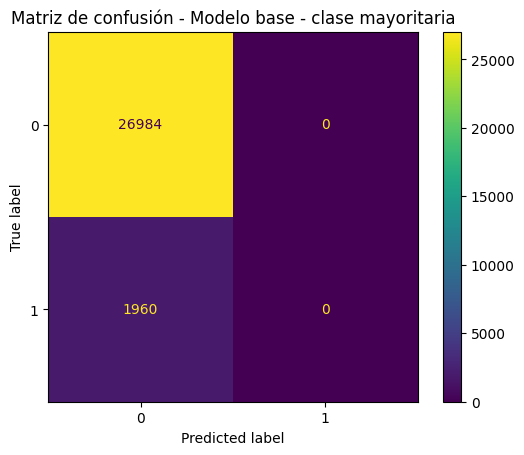

{'modelo': 'Modelo base - clase mayoritaria',
 'accuracy': 0.9322830292979547,
 'precision_clase_1': 0.0,
 'recall_clase_1': 0.0,
 'f1_clase_1': 0.0,
 'roc_auc': 0.5,
 'pr_auc': 0.06771697070204533}

In [45]:
from sklearn.dummy import DummyClassifier

# Preprocesamiento mínimo para modelo base no es necesario
modelo_base = DummyClassifier(strategy="most_frequent", random_state=42)
modelo_base.fit(X_train, y_train)

metricas_base = evaluar_modelo(
    "Modelo base - clase mayoritaria",
    modelo_base,
    X_test,
    y_test
)

metricas_base

## Modelos 1 y 2: Árbol de decisión y Regresión logística

Ambos modelos comparten el mismo esqueleto de preprocesamiento (imputación + One-Hot para categóricas) y solo difieren en si las variables numéricas se escalan o no. Se consolidan en un solo bucle sobre `construir_pipeline` para evitar duplicar la definición del `ColumnTransformer`.

- **Árbol de decisión:** interpretable y robusto a escalas distintas, no requiere `StandardScaler`. Se usa `class_weight='balanced'` para compensar el desbalance de la clase tardía.
- **Regresión logística:** modelo lineal de referencia. Sí requiere escalado de las numéricas para que la regularización trate a todas las variables en pie de igualdad. También con `class_weight='balanced'`.


Reporte de clasificación: Árbol de decisión
              precision    recall  f1-score   support

           0       0.96      0.75      0.84     26984
           1       0.15      0.60      0.23      1960

    accuracy                           0.74     28944
   macro avg       0.55      0.67      0.54     28944
weighted avg       0.91      0.74      0.80     28944



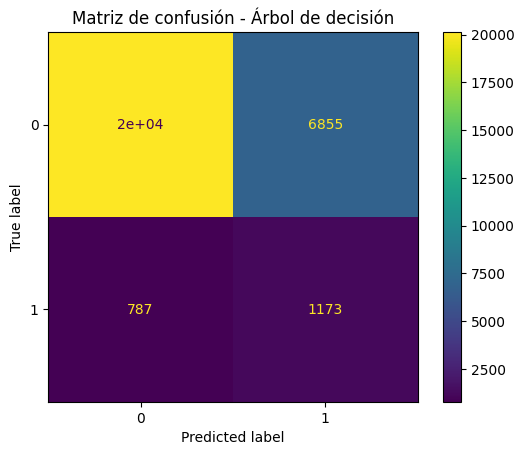

Reporte de clasificación: Regresión logística
              precision    recall  f1-score   support

           0       0.96      0.66      0.78     26984
           1       0.12      0.65      0.20      1960

    accuracy                           0.66     28944
   macro avg       0.54      0.65      0.49     28944
weighted avg       0.91      0.66      0.74     28944



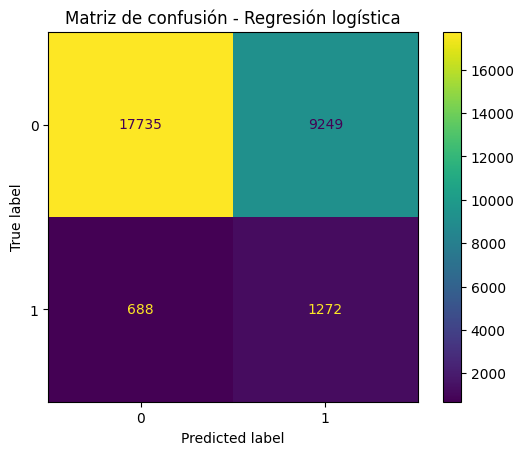

In [46]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression

def construir_pipeline(estimador, escalar_numericas):
    """Devuelve un Pipeline con imputacion + (opcional) escalado + OHE + estimador."""
    pasos_num = [('imputer', SimpleImputer(strategy='median'))]
    if escalar_numericas:
        pasos_num.append(('scaler', StandardScaler()))
    preprocesador = ColumnTransformer(transformers=[
        ('num', Pipeline(steps=pasos_num), variables_numericas),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), variables_categoricas),
    ])
    return Pipeline(steps=[('preprocesamiento', preprocesador), ('modelo', estimador)])

modelos_a_entrenar = {
    'Árbol de decisión': (
        DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced',
            max_depth=5,
            min_samples_leaf=50,
        ),
        False,  # arbol no requiere escalado
    ),
    'Regresión logística': (
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42,
        ),
        True,   # logistica si requiere escalado
    ),
}

modelos_entrenados = {}
metricas_modelos = {}
for nombre, (estimador, escalar) in modelos_a_entrenar.items():
    pipe = construir_pipeline(estimador, escalar_numericas=escalar)
    pipe.fit(X_train, y_train)
    modelos_entrenados[nombre] = pipe
    metricas_modelos[nombre] = evaluar_modelo(nombre, pipe, X_test, y_test)

# Alias para mantener compatibilidad con celdas posteriores.
modelo_arbol     = modelos_entrenados['Árbol de decisión']
modelo_logistica = modelos_entrenados['Regresión logística']
metricas_arbol     = metricas_modelos['Árbol de decisión']
metricas_logistica = metricas_modelos['Regresión logística']


### Importancia de variables en el árbol

Se revisan las variables más importantes para el árbol de decisión.  
Esto ayuda a interpretar qué atributos fueron más utilizados por el modelo para separar pedidos tardíos y no tardíos.

In [47]:
# Obtener nombres de variables después del One Hot Encoding

preprocesador_entrenado = modelo_arbol.named_steps["preprocesamiento"]
arbol_entrenado = modelo_arbol.named_steps["modelo"]

# Nombres numéricos
nombres_num = variables_numericas

# Nombres categóricos transformados
if len(variables_categoricas) > 0:
    onehot = preprocesador_entrenado.named_transformers_["cat"].named_steps["onehot"]
    nombres_cat = onehot.get_feature_names_out(variables_categoricas).tolist()
else:
    nombres_cat = []

nombres_features = nombres_num + nombres_cat

importancias = pd.DataFrame({
    "variable": nombres_features,
    "importancia": arbol_entrenado.feature_importances_
}).sort_values("importancia", ascending=False)

display(importancias.head(20))

,variable,importancia
2,mes,0.55
6,delivery_days_estimated,0.17
33,customer_state_SP,0.11
26,customer_state_RJ,0.09
18,customer_state_MG,0.04
12,customer_state_BA,0.02
1,payment_value,0.02
0,payment_installments,0.00
29,customer_state_RR,0.00
24,customer_state_PI,0.00


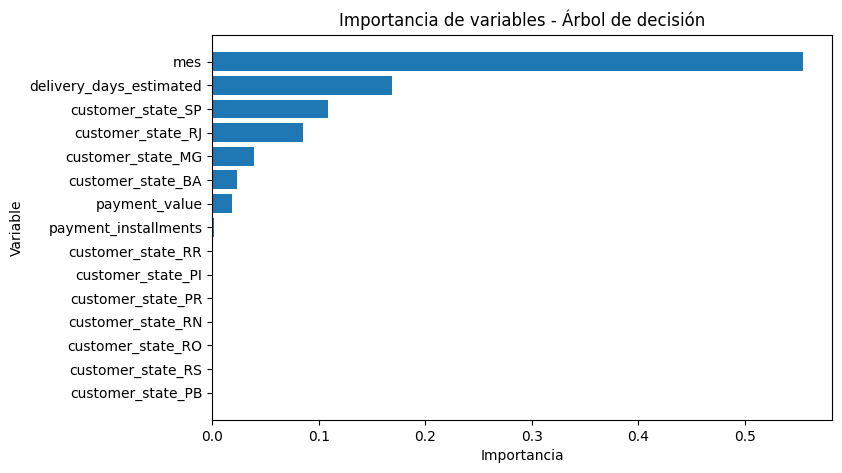

In [48]:
# Importancia de variables del árbol inicial (top 15).
plot_barh_top(
    importancias, col_label='variable', col_value='importancia',
    top_n=15, title='Importancia de variables - Árbol de decisión',
    xlabel='Importancia', ylabel='Variable',
)


## Comparación de modelos

Se comparan los resultados del modelo base, árbol de decisión y regresión logística.

Debido al desbalance de clases, la comparación se enfoca principalmente en el desempeño sobre la clase tardía.

In [49]:
resultados_modelos = pd.DataFrame([
    metricas_base,
    metricas_arbol,
    metricas_logistica
])

# Redondear métricas
resultados_modelos_redondeado = resultados_modelos.copy()
for col in resultados_modelos_redondeado.columns:
    if col != "modelo":
        resultados_modelos_redondeado[col] = resultados_modelos_redondeado[col].round(4)

display(resultados_modelos_redondeado)

,modelo,accuracy,precision_clase_1,recall_clase_1,f1_clase_1,roc_auc,pr_auc
0,Modelo base - clase mayoritaria,0.93,0.00,0.00,0.00,0.50,0.07
1,Árbol de decisión,0.74,0.15,0.60,0.23,0.72,0.17
2,Regresión logística,0.66,0.12,0.65,0.20,0.70,0.15


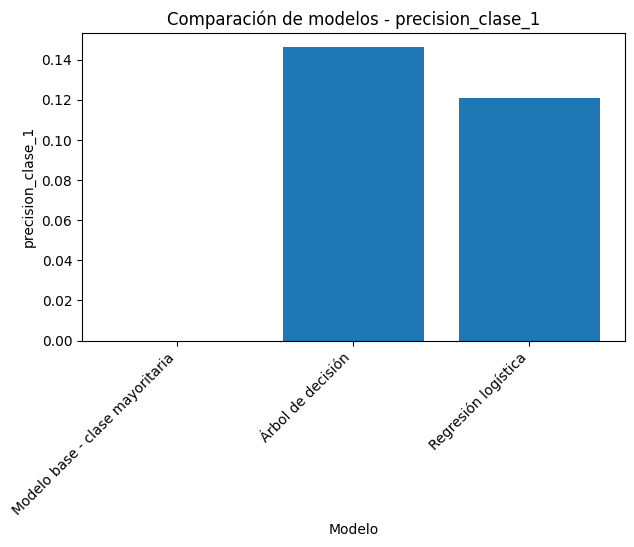

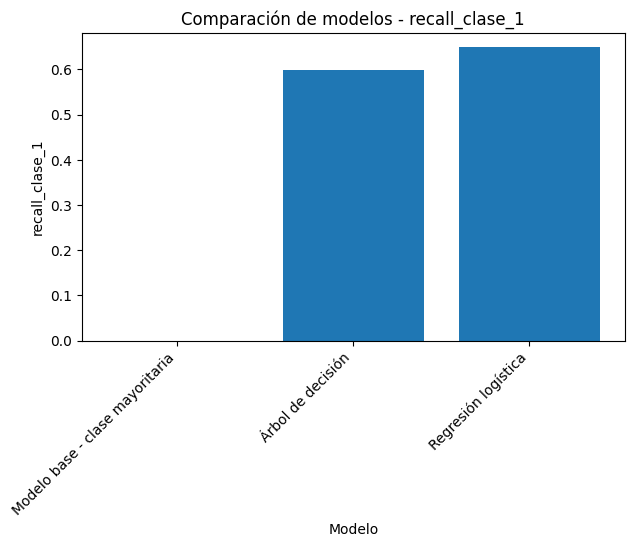

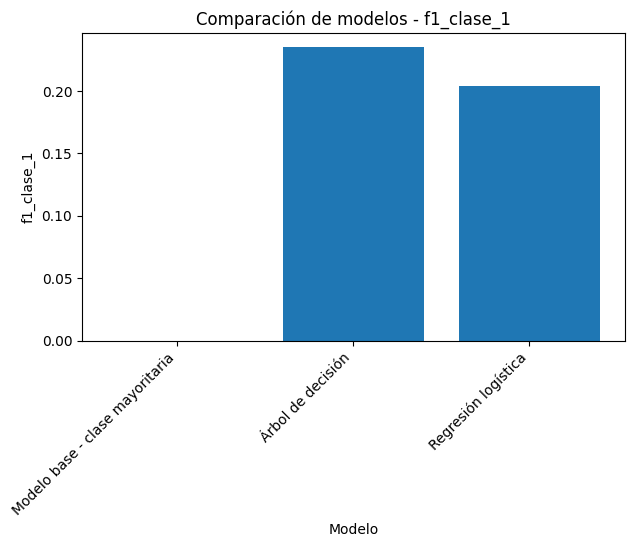

In [50]:
# Comparación de modelos: precision, recall, F1 (clase positiva).
for metrica in ['precision_clase_1', 'recall_clase_1', 'f1_clase_1']:
    plot_bar(
        resultados_modelos['modelo'], resultados_modelos[metrica],
        title=f'Comparación de modelos - {metrica}',
        xlabel='Modelo', ylabel=metrica,
        rotation=45,
    )


## Decisión preliminar del modelo

Con base en las métricas obtenidas, se seleccionará el modelo que ofrezca mejor equilibrio entre precision, recall y F1-score para la clase tardía.

Dado que el objetivo del proyecto es detectar pedidos con riesgo de retraso, se dará prioridad al recall de la clase `1`, sin descuidar excesivamente la precisión.

En la siguiente sección se realizará la hiperparametrización del árbol de decisión para intentar mejorar su desempeño.

In [51]:
# Guardar resultados para documentación
resultados_modelos_redondeado.to_csv(os.path.join(CSV_DIR, "05_resultados_modelos_supervisados.csv"), index=False)
importancias.to_csv(os.path.join(CSV_DIR, "05_importancias_arbol_decision.csv"), index=False)

print("Archivos guardados:")
print("- resultados_modelos_supervisados.csv")
print("- importancias_arbol_decision.csv")

Archivos guardados:
- resultados_modelos_supervisados.csv
- importancias_arbol_decision.csv


# Hiperparametrización del modelo

Después de entrenar los modelos supervisados base, se realiza una etapa de hiperparametrización sobre el árbol de decisión.

El objetivo es encontrar una mejor combinación de hiperparámetros que permita mejorar el desempeño del modelo, controlar su complejidad y evitar que el árbol sea demasiado simple o demasiado ajustado a los datos de entrenamiento.

Debido al desbalance de clases observado en `is_late_delivery`, no se optimiza el modelo únicamente con accuracy. En este caso se utiliza `f1` como métrica principal, ya que busca un equilibrio entre precision y recall para la clase tardía.

## Preparación del modelo para búsqueda exhaustiva

Se utilizará `GridSearchCV`, que prueba diferentes combinaciones de hiperparámetros mediante validación cruzada.

Los hiperparámetros evaluados serán:

- `criterion`: criterio de división del árbol.
- `max_depth`: profundidad máxima del árbol.
- `min_samples_split`: mínimo de observaciones necesarias para dividir un nodo.
- `min_samples_leaf`: mínimo de observaciones requeridas en una hoja.

El árbol mantiene `class_weight="balanced"` para compensar el desbalance entre pedidos tardíos y no tardíos.

In [52]:
from sklearn.model_selection import GridSearchCV

# Reutiliza construir_pipeline (definido al consolidar los modelos base)
# para mantener una unica fuente de verdad del preprocesamiento del arbol.
modelo_arbol_grid = construir_pipeline(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    escalar_numericas=False,
)

param_grid_arbol = {
    'modelo__criterion': ['gini', 'entropy'],
    'modelo__max_depth': [3, 5, 7, 9, 12],
    'modelo__min_samples_split': [50, 100, 200],
    'modelo__min_samples_leaf': [25, 50, 100],
}

grid_arbol = GridSearchCV(
    estimator=modelo_arbol_grid,
    param_grid=param_grid_arbol,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_arbol.fit(X_train, y_train)

print('Mejores hiperparámetros encontrados:')
print(grid_arbol.best_params_)
print('\nMejor F1 promedio en validación cruzada:', round(grid_arbol.best_score_, 4))


Fitting 3 folds for each of 90 candidates, totalling 270 fits


Mejores hiperparámetros encontrados:
{'modelo__criterion': 'entropy', 'modelo__max_depth': 5, 'modelo__min_samples_leaf': 50, 'modelo__min_samples_split': 50}

Mejor F1 promedio en validación cruzada: 0.2411


## Resultados de la búsqueda exhaustiva

Se revisan las mejores combinaciones encontradas por `GridSearchCV`.  
Esto permite observar qué configuraciones generaron mejor F1-score durante la validación cruzada.

In [53]:
# Convertir resultados de GridSearch en DataFrame
resultados_grid = pd.DataFrame(grid_arbol.cv_results_)

columnas_resultados = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_modelo__criterion",
    "param_modelo__max_depth",
    "param_modelo__min_samples_split",
    "param_modelo__min_samples_leaf"
]

resultados_grid_ordenado = resultados_grid[columnas_resultados].sort_values("rank_test_score")

display(resultados_grid_ordenado.head(10))

,rank_test_score,mean_test_score,std_test_score,param_modelo__criterion,param_modelo__max_depth,param_modelo__min_samples_split,param_modelo__min_samples_leaf
57,1,0.24,0.01,entropy,5,50,50
58,1,0.24,0.01,entropy,5,100,50
59,1,0.24,0.01,entropy,5,200,50
60,4,0.24,0.01,entropy,5,50,100
62,4,0.24,0.01,entropy,5,200,100
61,4,0.24,0.01,entropy,5,100,100
55,7,0.24,0.01,entropy,5,100,25
56,7,0.24,0.01,entropy,5,200,25
54,9,0.24,0.01,entropy,5,50,25
17,10,0.24,0.01,gini,5,200,100


## Evaluación del árbol ajustado

Una vez identificada la mejor combinación de hiperparámetros, se evalúa el árbol ajustado sobre el conjunto de prueba.

Se utilizan las mismas métricas de evaluación que en los modelos anteriores:

- Accuracy.
- Precision de la clase tardía.
- Recall de la clase tardía.
- F1-score de la clase tardía.
- ROC AUC.
- PR AUC.
- Matriz de confusión.

Reporte de clasificación: Árbol de decisión ajustado
              precision    recall  f1-score   support

           0       0.96      0.75      0.84     26984
           1       0.15      0.60      0.23      1960

    accuracy                           0.74     28944
   macro avg       0.55      0.67      0.54     28944
weighted avg       0.91      0.74      0.80     28944



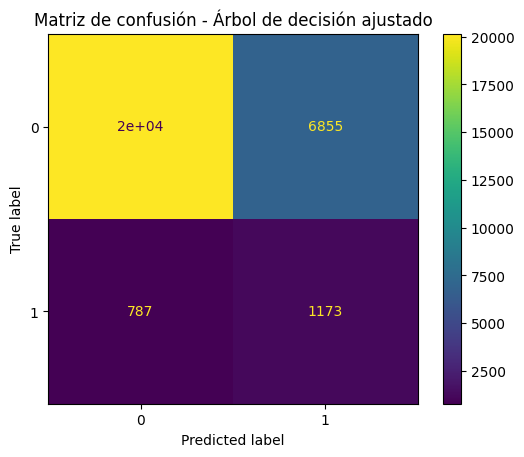

{'modelo': 'Árbol de decisión ajustado',
 'accuracy': 0.7359729132117192,
 'precision_clase_1': 0.1461136023916293,
 'recall_clase_1': 0.5984693877551021,
 'f1_clase_1': 0.23488185822987584,
 'roc_auc': 0.7201592345728685,
 'pr_auc': 0.1663525283702747}

In [54]:
# Mejor modelo encontrado
mejor_arbol = grid_arbol.best_estimator_

# Evaluación del árbol ajustado
metricas_arbol_ajustado = evaluar_modelo(
    "Árbol de decisión ajustado",
    mejor_arbol,
    X_test,
    y_test
)

metricas_arbol_ajustado

## Comparación del árbol ajustado contra los modelos anteriores

Se comparan los resultados del modelo base, árbol inicial, regresión logística y árbol ajustado.

La comparación se enfoca en la clase `1`, que representa los pedidos tardíos.

In [55]:
resultados_modelos_final = pd.DataFrame([
    metricas_base,
    metricas_arbol,
    metricas_logistica,
    metricas_arbol_ajustado
])

resultados_modelos_final_redondeado = resultados_modelos_final.copy()

for col in resultados_modelos_final_redondeado.columns:
    if col != "modelo":
        resultados_modelos_final_redondeado[col] = resultados_modelos_final_redondeado[col].round(4)

display(resultados_modelos_final_redondeado)

,modelo,accuracy,precision_clase_1,recall_clase_1,f1_clase_1,roc_auc,pr_auc
0,Modelo base - clase mayoritaria,0.93,0.00,0.00,0.00,0.50,0.07
1,Árbol de decisión,0.74,0.15,0.60,0.23,0.72,0.17
2,Regresión logística,0.66,0.12,0.65,0.20,0.70,0.15
3,Árbol de decisión ajustado,0.74,0.15,0.60,0.23,0.72,0.17


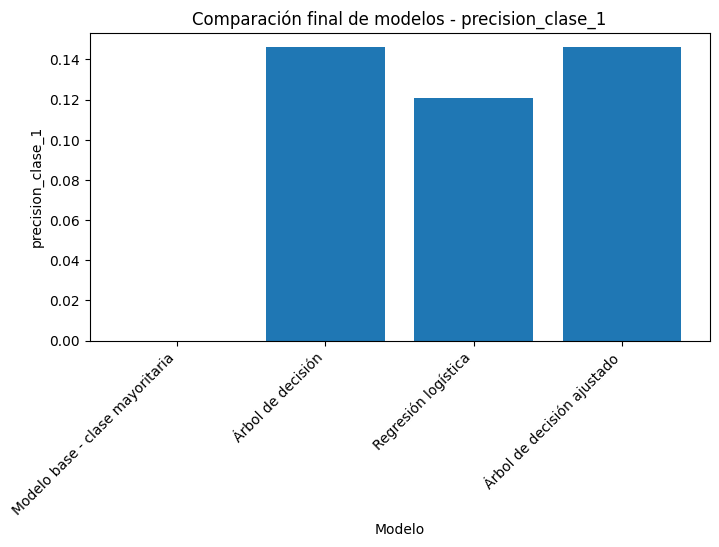

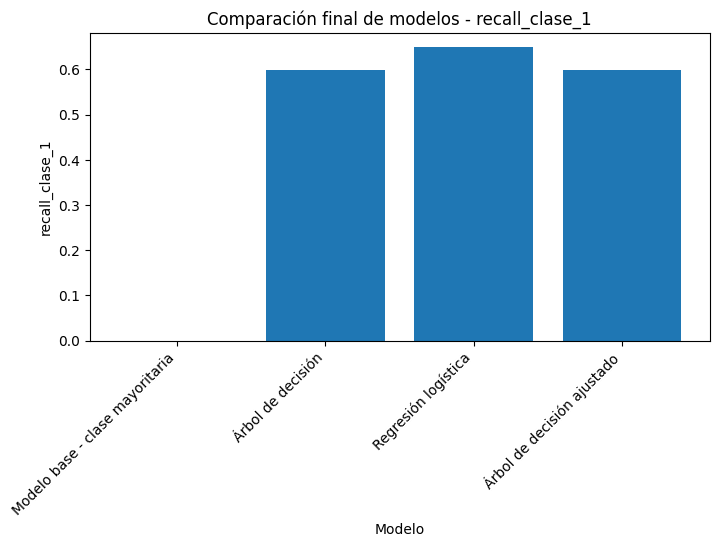

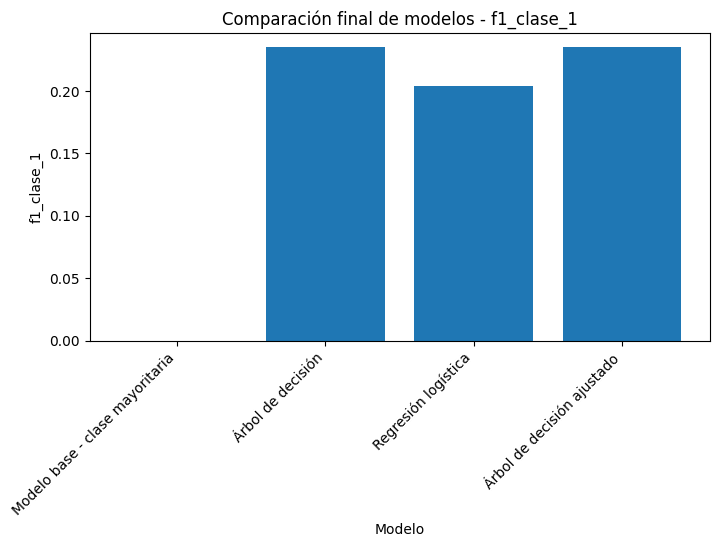

In [56]:
# Comparación final tras hiperparametrización.
for metrica in ['precision_clase_1', 'recall_clase_1', 'f1_clase_1']:
    plot_bar(
        resultados_modelos_final_redondeado['modelo'],
        resultados_modelos_final_redondeado[metrica],
        title=f'Comparación final de modelos - {metrica}',
        xlabel='Modelo', ylabel=metrica,
        figsize=(8, 4), rotation=45,
    )


## Importancia de variables del árbol ajustado

Se revisa la importancia de variables del árbol ajustado.  
Esto permite interpretar qué variables fueron más relevantes para clasificar pedidos tardíos y no tardíos.

In [57]:
# Obtener componentes entrenados del mejor árbol
preprocesador_ajustado = mejor_arbol.named_steps["preprocesamiento"]
arbol_ajustado = mejor_arbol.named_steps["modelo"]

# Nombres de variables numéricas
nombres_num = variables_numericas

# Nombres de variables categóricas después de One Hot Encoding
if len(variables_categoricas) > 0:
    onehot_ajustado = preprocesador_ajustado.named_transformers_["cat"].named_steps["onehot"]
    nombres_cat = onehot_ajustado.get_feature_names_out(variables_categoricas).tolist()
else:
    nombres_cat = []

nombres_features_ajustado = nombres_num + nombres_cat

importancias_arbol_ajustado = pd.DataFrame({
    "variable": nombres_features_ajustado,
    "importancia": arbol_ajustado.feature_importances_
}).sort_values("importancia", ascending=False)

display(importancias_arbol_ajustado.head(20))

,variable,importancia
2,mes,0.33
3,trimestre,0.21
6,delivery_days_estimated,0.17
33,customer_state_SP,0.11
26,customer_state_RJ,0.10
18,customer_state_MG,0.04
12,customer_state_BA,0.02
1,payment_value,0.02
0,payment_installments,0.00
29,customer_state_RR,0.00


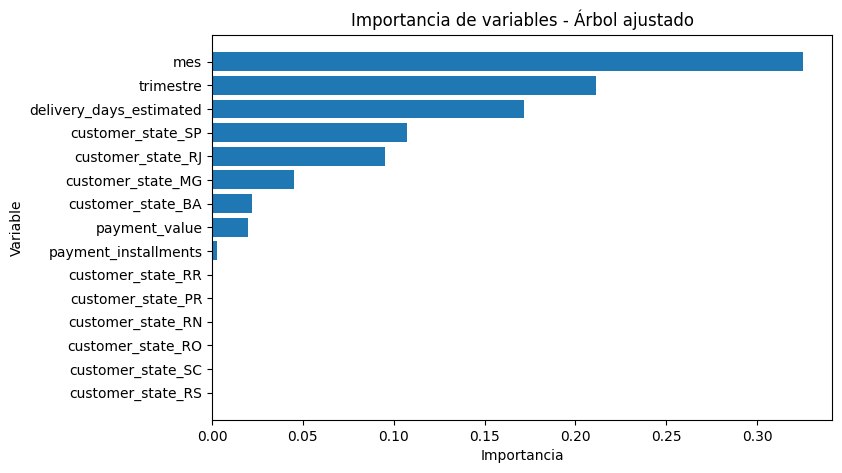

In [58]:
# Importancia de variables del árbol ajustado (top 15).
plot_barh_top(
    importancias_arbol_ajustado, col_label='variable', col_value='importancia',
    top_n=15, title='Importancia de variables - Árbol ajustado',
    xlabel='Importancia', ylabel='Variable',
)


## Comparación de importancias: árbol inicial vs árbol ajustado

Se compara la importancia de variables del árbol inicial contra el árbol ajustado para observar si la hiperparametrización cambió la forma en que el modelo toma decisiones.

In [59]:
# Comparación de importancias entre árbol inicial y árbol ajustado

importancias_inicial = importancias.copy()
importancias_inicial = importancias_inicial.rename(columns={"importancia": "importancia_arbol_inicial"})

importancias_ajustado = importancias_arbol_ajustado.copy()
importancias_ajustado = importancias_ajustado.rename(columns={"importancia": "importancia_arbol_ajustado"})

comparacion_importancias = pd.merge(
    importancias_inicial,
    importancias_ajustado,
    on="variable",
    how="outer"
).fillna(0)

comparacion_importancias["diferencia"] = (
    comparacion_importancias["importancia_arbol_ajustado"] -
    comparacion_importancias["importancia_arbol_inicial"]
)

comparacion_importancias = comparacion_importancias.sort_values(
    "importancia_arbol_ajustado",
    ascending=False
)

display(comparacion_importancias.head(20))

,variable,importancia_arbol_inicial,importancia_arbol_ajustado,diferencia
30,mes,0.55,0.33,-0.23
38,trimestre,0.00,0.21,0.21
27,delivery_days_estimated,0.17,0.17,0.00
25,customer_state_SP,0.11,0.11,-0.00
18,customer_state_RJ,0.09,0.10,0.01
10,customer_state_MG,0.04,0.04,0.01
4,customer_state_BA,0.02,0.02,-0.00
37,payment_value,0.02,0.02,0.00
32,payment_installments,0.00,0.00,0.00
34,payment_type_credit_card,0.00,0.00,0.00


## Selección del mejor modelo

La selección del mejor modelo se realiza considerando el objetivo del proyecto: identificar pedidos con riesgo de retraso.

Por esta razón, se revisa principalmente:

- `recall_clase_1`: capacidad para detectar pedidos tardíos.
- `precision_clase_1`: proporción de alertas correctas.
- `f1_clase_1`: equilibrio entre precision y recall.

Si el árbol ajustado mejora el F1-score de la clase tardía, se selecciona como mejor modelo.  
Si no mejora de forma significativa, se puede conservar el árbol inicial por ser más simple e interpretable.

In [60]:
# Selección automática del mejor modelo según F1 de clase 1

mejor_modelo_f1 = resultados_modelos_final_redondeado.sort_values(
    "f1_clase_1",
    ascending=False
).iloc[0]

print("Mejor modelo según F1-score de clase tardía:")
display(mejor_modelo_f1)

Mejor modelo según F1-score de clase tardía:


modelo               Árbol de decisión
accuracy                          0.74
precision_clase_1                 0.15
recall_clase_1                    0.60
f1_clase_1                        0.23
roc_auc                           0.72
pr_auc                            0.17
Name: 1, dtype: object

## Guardado de resultados

Se guardan los resultados de la hiperparametrización, la comparación final de modelos y la importancia de variables del árbol ajustado.

In [61]:
# Persistir resultados del modelado supervisado.
outputs = [
    (resultados_modelos_final_redondeado, '05_resultados_modelos_final.csv'),
    (resultados_grid_ordenado,             '05_resultados_gridsearch.csv'),
    (importancias_arbol_ajustado,          '05_importancias_arbol_ajustado.csv'),
    (comparacion_importancias,             '05_comparacion_importancias.csv'),
]
print('Archivos guardados en CSV/:')
for df, nombre in outputs:
    df.to_csv(os.path.join(CSV_DIR, nombre), index=False)
    print(f' - {nombre}')


Archivos guardados en CSV/:
 - 05_resultados_modelos_final.csv
 - 05_resultados_gridsearch.csv
 - 05_importancias_arbol_ajustado.csv
 - 05_comparacion_importancias.csv
